样本量: 13446
nonwhite分布: {0: 8806, 1: 4640}
low_visibility分布: {0: 8996, 1: 4450}

R-squared: 0.0467

提取到的系数：
    time      coef        se
0    -12 -0.041100  0.050790
1    -11 -0.058150  0.050210
2    -10 -0.146728  0.047235
3     -9 -0.009932  0.049687
4     -8 -0.043168  0.055871
5     -7 -0.052075  0.052427
6     -6 -0.023406  0.051612
7     -5 -0.004656  0.051659
8     -4 -0.011224  0.045797
9     -3  0.055601  0.046240
10    -2 -0.047966  0.044559
11    -1  0.000000  0.000000
12     1 -0.016769  0.049546
13     2 -0.066762  0.047821
14     3 -0.010075  0.046056
15     4 -0.039682  0.048481
16     5  0.010235  0.047962
17     6  0.032189  0.043914
18     7 -0.012288  0.046678
19     8 -0.068508  0.046883
20     9  0.030048  0.046913
21    10 -0.049388  0.049127
22    11 -0.013070  0.047276
23    12 -0.046893  0.046328

找到 11 个预处理期三重交互项
Pre-trend F-test: F=1.7534, p=0.0563


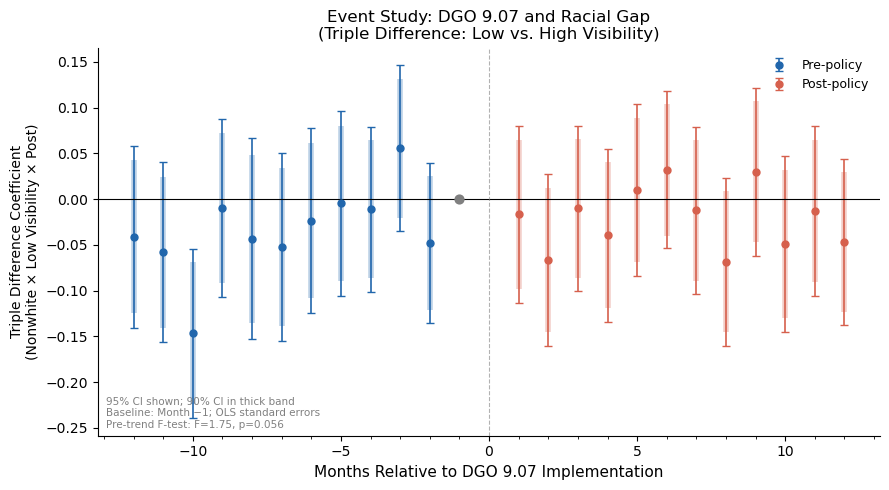

In [9]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import re

# ── 数据准备 ──────────────────────────────────────────
df = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

df["stop_datetime"] = pd.to_datetime(df["stop_datetime"], errors="coerce")
df["month"] = df["stop_datetime"].dt.to_period("M")
df["month_fe"] = df["month"].astype(str)

policy_month = pd.Period("2024-07", freq="M")
df["event_time"] = (df["month"] - policy_month).apply(lambda x: x.n)

# ── 筛选 ──────────────────────────────────────────────
WINDOW = 12
df_event = df[
    (df["reason_for_stop_code"] == 1) &
    (df["event_time"] >= -WINDOW) &
    (df["event_time"] <= WINDOW) &
    (df["event_time"] != 0) &
    (df["perceived_race_code"].isin([2, 7]))
].dropna(subset=["searched", "event_time", "low_visibility", "district", "month_fe"]).copy()

df_event["district"] = df_event["district"].astype(str)
df_event["nonwhite"] = (df_event["perceived_race_code"] == 2).astype(int)
df_event["low_visibility"] = df_event["low_visibility"].astype(int)

print("样本量:", len(df_event))
print("nonwhite分布:", df_event["nonwhite"].value_counts().to_dict())
print("low_visibility分布:", df_event["low_visibility"].value_counts().to_dict())

# ── Triple Difference 回归 ─────────────────────────────
model = smf.ols(
    "searched ~ C(event_time, Treatment(-1))*nonwhite*low_visibility "
    "+ C(district) + C(month_fe)",
    data=df_event
).fit()

print("\nR-squared:", round(model.rsquared, 4))

# ── 系数提取：三重交互项 ───────────────────────────────
def extract_triple_diff(model):
    params = model.params
    bse = model.bse

    # 找 event_time × nonwhite × low_visibility 三重交互项
    mask = (
        params.index.str.contains("event_time") &
        params.index.str.contains("nonwhite") &
        params.index.str.contains("low_visibility")
    )

    coefs = params[mask]
    ses = bse[mask]

    def parse_time(s):
        match = re.search(r"\[T\.(-?\d+)\]", s)
        return int(match.group(1)) if match else None

    times = [parse_time(i) for i in coefs.index]
    valid = [(t, c, s) for t, c, s in zip(times, coefs.values, ses.values)
             if t is not None]

    if not valid:
        print("警告：未找到三重交互项，检查变量名")
        return pd.DataFrame()

    times, coef_vals, se_vals = zip(*valid)

    df_out = pd.DataFrame({
        "time": times,
        "coef": coef_vals,
        "se": se_vals
    }).sort_values("time").reset_index(drop=True)

    baseline = pd.DataFrame({"time": [-1], "coef": [0.0], "se": [0.0]})
    df_out = pd.concat([df_out, baseline]).sort_values("time").reset_index(drop=True)

    return df_out

results = extract_triple_diff(model)
print("\n提取到的系数：")
print(results[["time", "coef", "se"]])

# ── F检验预处理趋势 ────────────────────────────────────
pre_terms = [name for name in model.params.index
             if "nonwhite" in name
             and "low_visibility" in name
             and re.search(r"\[T\.(-1[012]|-[2-9])\]", name)]

print(f"\n找到 {len(pre_terms)} 个预处理期三重交互项")

if pre_terms:
    f_test = model.f_test([f"{term} = 0" for term in pre_terms])
    print(f"Pre-trend F-test: F={f_test.fvalue:.4f}, p={f_test.pvalue:.4f}")
    f_stat = f_test.fvalue
    f_pval = f_test.pvalue
else:
    print("未找到预处理期项，跳过F检验")
    f_stat, f_pval = None, None

# ── 画图 ──────────────────────────────────────────────
if len(results) == 0:
    print("无法画图，系数提取失败")
else:
    fig, ax = plt.subplots(figsize=(9, 5))

    pre  = results[results["time"] < 0]
    post = results[results["time"] > 0]

    for subset, color, label in [
        (pre,  "#2166ac", "Pre-policy"),
        (post, "#d6604d", "Post-policy"),
    ]:
        # 90% CI
        ax.errorbar(
            subset["time"], subset["coef"],
            yerr=1.645 * subset["se"],
            fmt="none", color=color, alpha=0.3, capsize=0, linewidth=4,
        )
        # 95% CI
        ax.errorbar(
            subset["time"], subset["coef"],
            yerr=1.96 * subset["se"],
            fmt="o", color=color, capsize=3, linewidth=1.2,
            markersize=5, label=label
        )

    ax.scatter([-1], [0], color="gray", zorder=5, s=40)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, linestyle="--", color="gray", linewidth=0.8, alpha=0.6)

    ax.set_xlabel("Months Relative to DGO 9.07 Implementation", fontsize=11)
    ax.set_ylabel("Triple Difference Coefficient\n(Nonwhite × Low Visibility × Post)", fontsize=10)
    ax.set_title("Event Study: DGO 9.07 and Racial Gap\n(Triple Difference: Low vs. High Visibility)", fontsize=12)

    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    note = "95% CI shown; 90% CI in thick band\nBaseline: Month −1; OLS standard errors"
    if f_stat is not None:
        note += f"\nPre-trend F-test: F={f_stat:.2f}, p={f_pval:.3f}"
    ax.annotate(note, xy=(0.01, 0.02), xycoords="axes fraction",
                fontsize=7.5, color="gray")

    plt.tight_layout()
    plt.savefig("event_study_triple_diff.pdf", dpi=300, bbox_inches="tight")
    plt.show()

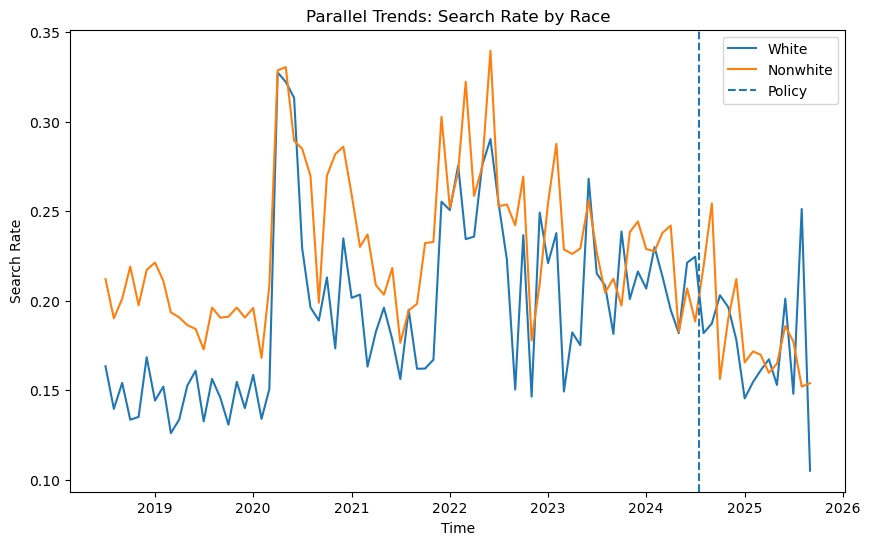

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1. Load data
# =====================
df = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
    low_memory=False
)

df["date"] = pd.to_datetime(df["date"])

# race indicator
df["white"] = (df["perceived_race_code"] == 7).astype(int)
df["nonwhite"] = 1 - df["white"]

df["searched"] = pd.to_numeric(df["searched"], errors="coerce")

# =====================
# 2. Monthly average
# =====================
df["month"] = df["date"].dt.to_period("M")

white_rate = (
    df[df["white"] == 1]
    .groupby("month")["searched"]
    .mean()
)

nonwhite_rate = (
    df[df["nonwhite"] == 1]
    .groupby("month")["searched"]
    .mean()
)

trend = pd.DataFrame({
    "white": white_rate,
    "nonwhite": nonwhite_rate
}).reset_index()

trend["month"] = trend["month"].dt.to_timestamp()

# =====================
# 3. Policy date
# =====================
policy_date = pd.Timestamp("2024-07-17")

# =====================
# 4. Plot
# =====================
plt.figure(figsize=(10,6))

plt.plot(trend["month"], trend["white"], label="White")
plt.plot(trend["month"], trend["nonwhite"], label="Nonwhite")

plt.axvline(policy_date, linestyle="--", label="Policy")

plt.xlabel("Time")
plt.ylabel("Search Rate")
plt.title("Parallel Trends: Search Rate by Race")

plt.legend()

plt.show()

/var/folders/jy/pc_qtmgx7vg538t3wpxxq4n00000gn/T/ipykernel_40589/2189016884.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(gap)


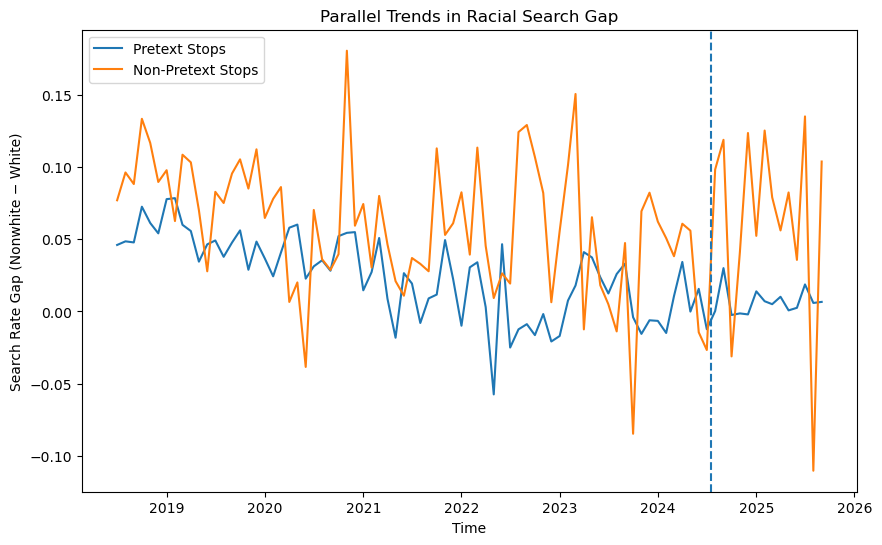

In [15]:
df["pretext"] = (df["reason_for_stop_code"] == 1).astype(int)

df["month"] = df["date"].dt.to_period("M")

# racial gap function
def gap(data):
    return data.loc[data["nonwhite"] == 1, "searched"].mean() - \
           data.loc[data["white"] == 1, "searched"].mean()

gap_series = (
    df.groupby(["month","pretext"])
    .apply(gap)
    .reset_index(name="gap")
)

gap_series["month"] = gap_series["month"].dt.to_timestamp()

pretext = gap_series[gap_series["pretext"] == 1]
non_pretext = gap_series[gap_series["pretext"] == 0]

plt.figure(figsize=(10,6))

plt.plot(pretext["month"], pretext["gap"], label="Pretext Stops")
plt.plot(non_pretext["month"], non_pretext["gap"], label="Non-Pretext Stops")

plt.axvline(policy_date, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Search Rate Gap (Nonwhite − White)")
plt.title("Parallel Trends in Racial Search Gap")

plt.legend()

plt.show()

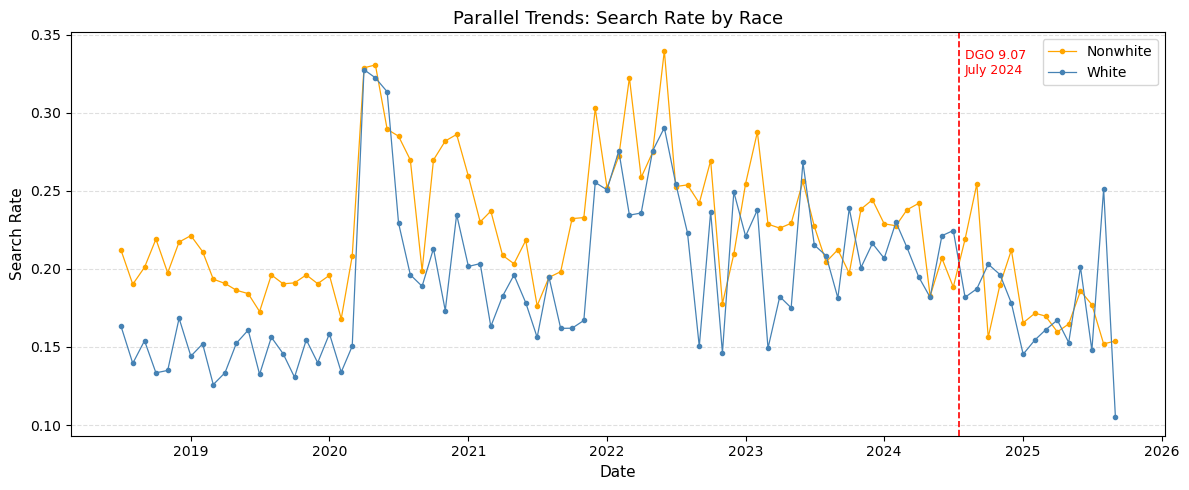

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 读取数据
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

# 2. 日期
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")

# 3. 种族变量
df["nonwhite"] = (df["perceived_race_code"] != 7).astype(int)

# 4. 按月聚合
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby(["month", "nonwhite"])["searched"].mean().reset_index()

white    = monthly[monthly["nonwhite"] == 0]
nonwhite = monthly[monthly["nonwhite"] == 1]

# 5. 画图
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(nonwhite["month"], nonwhite["searched"],
        color="orange", marker="o", markersize=3,
        linewidth=0.9, label="Nonwhite")
ax.plot(white["month"], white["searched"],
        color="steelblue", marker="o", markersize=3,
        linewidth=0.9, label="White")

# Policy line
policy_date = pd.Timestamp("2024-07-17")
ax.axvline(policy_date, color="red", linestyle="--", linewidth=1.2)
ax.text(policy_date + pd.DateOffset(days=15), ax.get_ylim()[1] * 0.97,
        "DGO 9.07\nJuly 2024", color="red", fontsize=9, va="top")

# Formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Search Rate", fontsize=11)
ax.set_title("Parallel Trends: Search Rate by Race", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("/Users/thisisjasmine/Desktop/parallel_trends_python.png",
            dpi=150, bbox_inches="tight")
plt.show()

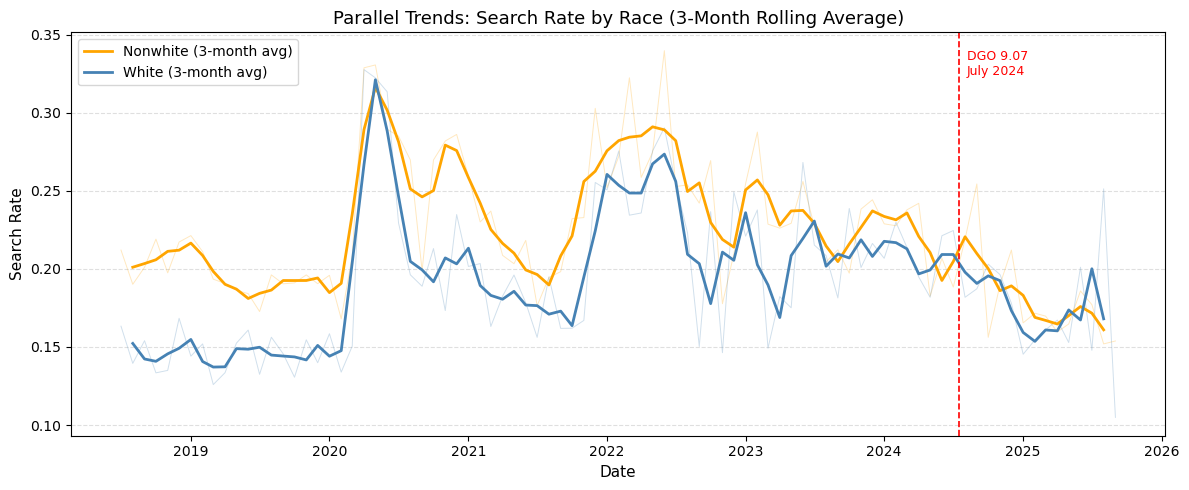

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 读取数据
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

# 2. 日期
df["date"] = pd.to_datetime(df["date"])

# 3. 种族变量
df["nonwhite"] = (df["perceived_race_code"] != 7).astype(int)

# 4. 按月聚合
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby(["month", "nonwhite"])["searched"].mean().reset_index()

white    = monthly[monthly["nonwhite"] == 0].copy().sort_values("month")
nonwhite = monthly[monthly["nonwhite"] == 1].copy().sort_values("month")

# 5. 3-month rolling average
white["rolling"]    = white["searched"].rolling(window=3, center=True).mean()
nonwhite["rolling"] = nonwhite["searched"].rolling(window=3, center=True).mean()

# 6. 画图
fig, ax = plt.subplots(figsize=(12, 5))

# 原始数据淡化显示
ax.plot(nonwhite["month"], nonwhite["searched"],
        color="orange", alpha=0.25, linewidth=0.7)
ax.plot(white["month"], white["searched"],
        color="steelblue", alpha=0.25, linewidth=0.7)

# Rolling average加粗显示
ax.plot(nonwhite["month"], nonwhite["rolling"],
        color="orange", linewidth=2, label="Nonwhite (3-month avg)")
ax.plot(white["month"], white["rolling"],
        color="steelblue", linewidth=2, label="White (3-month avg)")

# Policy line
policy_date = pd.Timestamp("2024-07-17")
ax.axvline(policy_date, color="red", linestyle="--", linewidth=1.2)
ax.text(policy_date + pd.DateOffset(days=20), 0.34,
        "DGO 9.07\nJuly 2024", color="red", fontsize=9, va="top")

# Formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Search Rate", fontsize=11)
ax.set_title("Parallel Trends: Search Rate by Race (3-Month Rolling Average)",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("/Users/thisisjasmine/Desktop/parallel_trends_rolling.png",
            dpi=150, bbox_inches="tight")
plt.show()

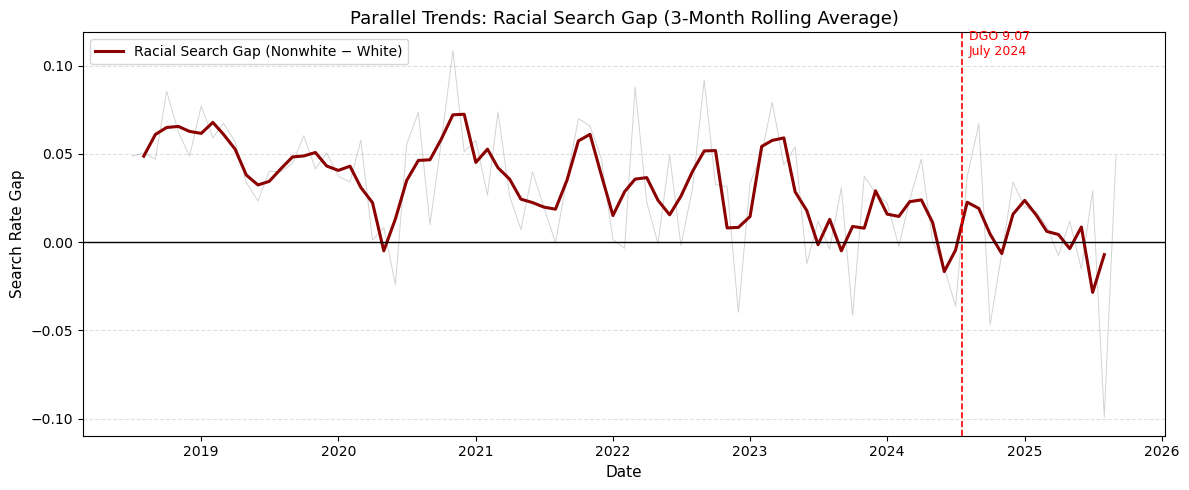

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 读取数据
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

# 2. 日期
df["date"] = pd.to_datetime(df["date"])

# 3. 种族变量
df["nonwhite"] = (df["perceived_race_code"] != 7).astype(int)

# 4. 按月计算 search rate
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df.groupby(["month", "nonwhite"])["searched"]
    .mean()
    .unstack()
    .reset_index()
)

monthly.columns = ["month", "white", "nonwhite"]

# 5. 计算 racial search gap
monthly["gap"] = monthly["nonwhite"] - monthly["white"]

# 6. rolling average
monthly["gap_roll"] = monthly["gap"].rolling(window=3, center=True).mean()

# 7. 画图
fig, ax = plt.subplots(figsize=(12,5))

# 原始gap（淡）
ax.plot(monthly["month"], monthly["gap"],
        color="gray", alpha=0.35, linewidth=0.7)

# rolling gap（主线）
ax.plot(monthly["month"], monthly["gap_roll"],
        color="darkred", linewidth=2.2,
        label="Racial Search Gap (Nonwhite − White)")

# policy line
policy_date = pd.Timestamp("2024-07-17")
ax.axvline(policy_date, color="red", linestyle="--", linewidth=1.2)

ax.text(policy_date + pd.DateOffset(days=20), 0.12,
        "DGO 9.07\nJuly 2024",
        color="red", fontsize=9, va="top")

# formatting
ax.axhline(0, color="black", linewidth=1)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Search Rate Gap", fontsize=11)

ax.set_title(
    "Parallel Trends: Racial Search Gap (3-Month Rolling Average)",
    fontsize=13
)

ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "/Users/thisisjasmine/Desktop/parallel_trends_gap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

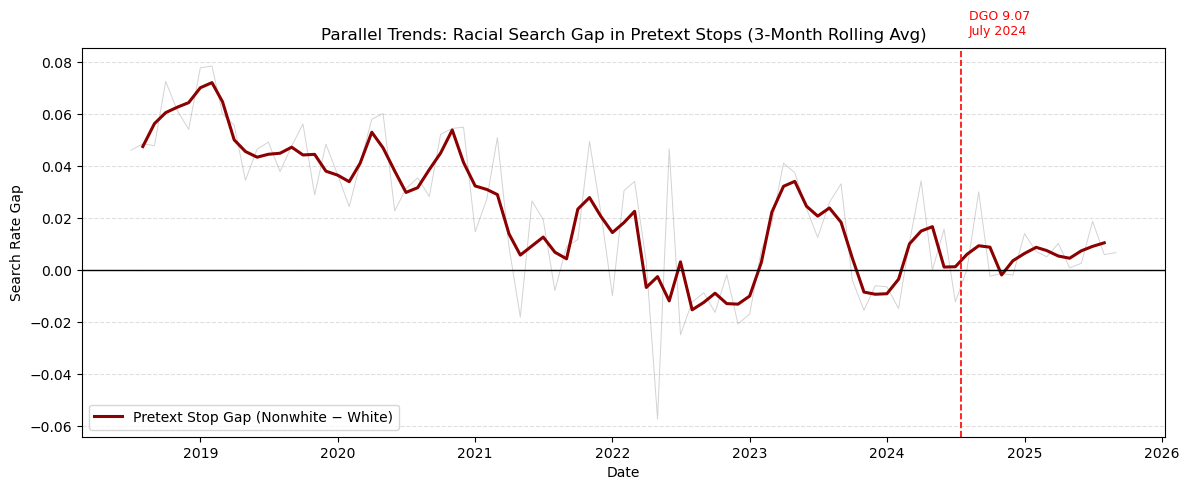

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 读取数据
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

# 2. 日期
df["date"] = pd.to_datetime(df["date"])

# 3. race variable
df["nonwhite"] = (df["perceived_race_code"] != 7).astype(int)

# 4. 只保留 pretext stops
df = df[df["reason_for_stop_code"] == 1]

# 5. 按月计算 search rate
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df.groupby(["month", "nonwhite"])["searched"]
    .mean()
    .unstack()
    .reset_index()
)

monthly.columns = ["month", "white", "nonwhite"]

# 6. 计算 racial search gap
monthly["gap"] = monthly["nonwhite"] - monthly["white"]

# 7. rolling average
monthly["gap_roll"] = monthly["gap"].rolling(window=3, center=True).mean()

# 8. 画图
fig, ax = plt.subplots(figsize=(12,5))

# 原始gap
ax.plot(monthly["month"], monthly["gap"],
        color="gray", alpha=0.35, linewidth=0.7)

# rolling gap
ax.plot(monthly["month"], monthly["gap_roll"],
        color="darkred", linewidth=2.2,
        label="Pretext Stop Gap (Nonwhite − White)")

# policy line
policy_date = pd.Timestamp("2024-07-17")
ax.axvline(policy_date, color="red", linestyle="--", linewidth=1.2)

ax.text(policy_date + pd.DateOffset(days=20), 0.10,
        "DGO 9.07\nJuly 2024",
        color="red", fontsize=9, va="top")

# formatting
ax.axhline(0, color="black", linewidth=1)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_xlabel("Date")
ax.set_ylabel("Search Rate Gap")

ax.set_title(
    "Parallel Trends: Racial Search Gap in Pretext Stops (3-Month Rolling Avg)"
)

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "/Users/thisisjasmine/Desktop/pretext_gap_trend.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

=== 样本概况 ===
Total stops:        168,596
Traffic stops:      90,823
Non-traffic stops:  77,773
Black stops:        70,311
White stops:        98,285

Search rate overall:        0.226
Search rate - traffic:      0.077
Search rate - non-traffic:  0.400

Consent search rate overall:       0.0147
Consent search rate - traffic:     0.0061
Consent search rate - non-traffic: 0.0247


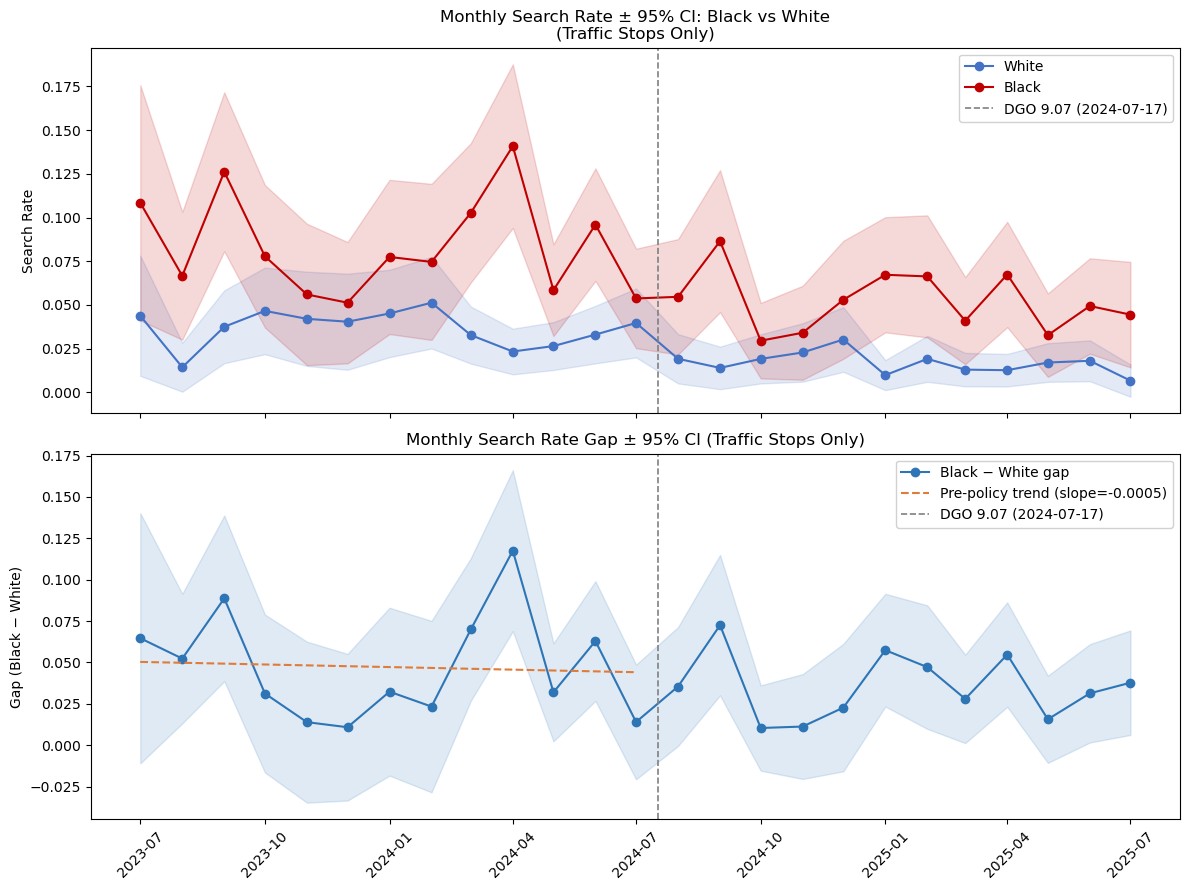


Parallel Trends Test: Black vs White
Traffic Stops Only, Pre 12 Months
                            OLS Regression Results                            
Dep. Variable:               searched   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     21.53
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           7.17e-14
Time:                        21:48:47   Log-Likelihood:                 468.31
No. Observations:                6505   AIC:                            -928.6
Df Residuals:                    6501   BIC:                            -901.5
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

# 只保留 Black (code=2) 和 White (code=7)
df = df[df["perceived_race_code"].isin([2, 7])].copy()
df["black"]        = (df["perceived_race_code"] == 2).astype(int)
df["traffic_stop"] = (df["reason_for_stop_code"] == 1).astype(int)
df["post_DGO"]     = (df["date"] >= policy_date).astype(int)
df["month"]        = df["date"].dt.to_period("M").dt.to_timestamp()
df["reason_1"]     = (df["reason_for_stop_code"] == 1).astype(int)

# consent search indicator（basis_for_search_code 含 "1"）
df["consent_search"] = (
    df["searched"] == 1
) & (
    df["basis_for_search_code"].astype(str).str.split(",")
    .apply(lambda x: any(v.strip() == "1" for v in x))
)
df["consent_search"] = df["consent_search"].astype(int)

print("=== 样本概况 ===")
print(f"Total stops:        {len(df):,}")
print(f"Traffic stops:      {df['traffic_stop'].sum():,}")
print(f"Non-traffic stops:  {(df['traffic_stop']==0).sum():,}")
print(f"Black stops:        {df['black'].sum():,}")
print(f"White stops:        {(df['black']==0).sum():,}")
print(f"\nSearch rate overall:        {df['searched'].mean():.3f}")
print(f"Search rate - traffic:      {df[df['traffic_stop']==1]['searched'].mean():.3f}")
print(f"Search rate - non-traffic:  {df[df['traffic_stop']==0]['searched'].mean():.3f}")
print(f"\nConsent search rate overall:       {df['consent_search'].mean():.4f}")
print(f"Consent search rate - traffic:     {df[df['traffic_stop']==1]['consent_search'].mean():.4f}")
print(f"Consent search rate - non-traffic: {df[df['traffic_stop']==0]['consent_search'].mean():.4f}")

# =========================
# 2. ±12 个月窗口
# =========================
start  = policy_date - pd.DateOffset(months=12)
end    = policy_date + pd.DateOffset(months=12)
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

# =========================
# 3. 平行趋势图（traffic stop 中 Black vs White）
# =========================
df_traffic = df_win[df_win["traffic_stop"] == 1].copy()

ms = (
    df_traffic.groupby(["month", "black"])["searched"]
    .agg(mean="mean", sem=lambda x: stats.sem(x))
    .reset_index()
)
ms["ci95"] = ms["sem"] * 1.96
wide = ms.pivot(index="month", columns="black", values=["mean", "ci95"])
wide.columns = ["_".join(map(str, c)) for c in wide.columns]
wide["gap_mean"] = wide["mean_1"] - wide["mean_0"]
wide["gap_ci"]   = np.sqrt(wide["ci95_1"]**2 + wide["ci95_0"]**2)

# pre期趋势线
pre_wide    = wide[wide.index < policy_date].copy()
pre_wide["t"] = np.arange(len(pre_wide))
z           = np.polyfit(pre_wide["t"], pre_wide["gap_mean"], 1)
trend_vals  = np.polyval(z, pre_wide["t"])

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# 上图：Black vs White search rate（traffic stops only）
for col, label, color in [("mean_0", "White", "#4472C4"),
                           ("mean_1", "Black",  "#C00000")]:
    ci_col = col.replace("mean", "ci95")
    axes[0].plot(wide.index, wide[col], marker="o",
                 label=label, color=color, linewidth=1.5)
    axes[0].fill_between(wide.index,
                         wide[col] - wide[ci_col],
                         wide[col] + wide[ci_col],
                         alpha=0.15, color=color)

axes[0].axvline(policy_date, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[0].set_ylabel("Search Rate")
axes[0].set_title("Monthly Search Rate ± 95% CI: Black vs White\n(Traffic Stops Only)")
axes[0].legend(framealpha=0.9)

# 下图：gap + 趋势线
axes[1].plot(wide.index, wide["gap_mean"], marker="o",
             color="#2E75B6", linewidth=1.5, label="Black − White gap")
axes[1].fill_between(wide.index,
                     wide["gap_mean"] - wide["gap_ci"],
                     wide["gap_mean"] + wide["gap_ci"],
                     alpha=0.15, color="#2E75B6")
axes[1].plot(pre_wide.index, trend_vals,
             color="#E07B39", linewidth=1.5, linestyle="--",
             label=f"Pre-policy trend (slope={z[0]:.4f})")
axes[1].axvline(policy_date, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[1].set_ylabel("Gap (Black − White)")
axes[1].set_title("Monthly Search Rate Gap ± 95% CI (Traffic Stops Only)")
axes[1].legend(framealpha=0.9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_parallel_trends_traffic.png",
            dpi=150, bbox_inches="tight")
plt.show()

# =========================
# 4. 平行趋势检验（traffic stop 中，政策前12个月）
# =========================
pre_traffic = df_traffic[df_traffic["date"] < policy_date].copy()
pre_traffic["month_trend"] = (
    (pre_traffic["date"].dt.year  - pre_traffic["date"].dt.year.min()) * 12 +
    (pre_traffic["date"].dt.month - pre_traffic["date"].dt.month.min())
)

pt_model = smf.ols(
    "searched ~ black + month_trend + black:month_trend",
    data=pre_traffic
).fit(cov_type="HC1")

print("\n==============================")
print("Parallel Trends Test: Black vs White")
print("Traffic Stops Only, Pre 12 Months")
print("==============================")
print(pt_model.summary())
print(f"\nblack:month_trend = {pt_model.params['black:month_trend']:.6f}")
print(f"p-value           = {pt_model.pvalues['black:month_trend']:.4f}")
if pt_model.pvalues["black:month_trend"] > 0.1:
    print("→ 平行趋势成立 ✓")
else:
    print("→ 警告：平行趋势可能违背")

# =========================
# 5. Triple DID
#    searched ~ post × traffic_stop × black + controls + FE
#    核心问题：DGO 9.07 是否减少了 traffic stop 中 Black vs White 的搜查差距
# =========================
print("\n==============================")
print("Triple DID: post × traffic_stop × black")
print("Outcome: searched")
print("==============================")

did3 = smf.ols(
    """searched ~ post_DGO * traffic_stop * black
       + low_visibility + C(district)""",
    data=df_win
).fit(cov_type="HC1")

print(did3.summary())

key_coef = "post_DGO:traffic_stop:black"
print(f"\n=== 核心系数 ===")
print(f"{key_coef} = {did3.params[key_coef]:.6f}")
print(f"p-value          = {did3.pvalues[key_coef]:.4f}")
if did3.pvalues[key_coef] < 0.05:
    direction = "减少" if did3.params[key_coef] < 0 else "增加"
    print(f"→ 显著：政策使 traffic stop 中 Black-White 搜查差距{direction}")
else:
    print("→ 不显著：政策未显著改变 traffic stop 中的 Black-White 搜查差距")

# =========================
# 6. 同样的 Triple DID，outcome 换成 consent_search
# =========================
print("\n==============================")
print("Triple DID: post × traffic_stop × black")
print("Outcome: consent_search")
print("==============================")

did3_consent = smf.ols(
    """consent_search ~ post_DGO * traffic_stop * black
       + low_visibility + C(district)""",
    data=df_win
).fit(cov_type="HC1")

print(did3_consent.summary())
print(f"\n=== 核心系数（consent search）===")
print(f"{key_coef} = {did3_consent.params[key_coef]:.6f}")
print(f"p-value          = {did3_consent.pvalues[key_coef]:.4f}")

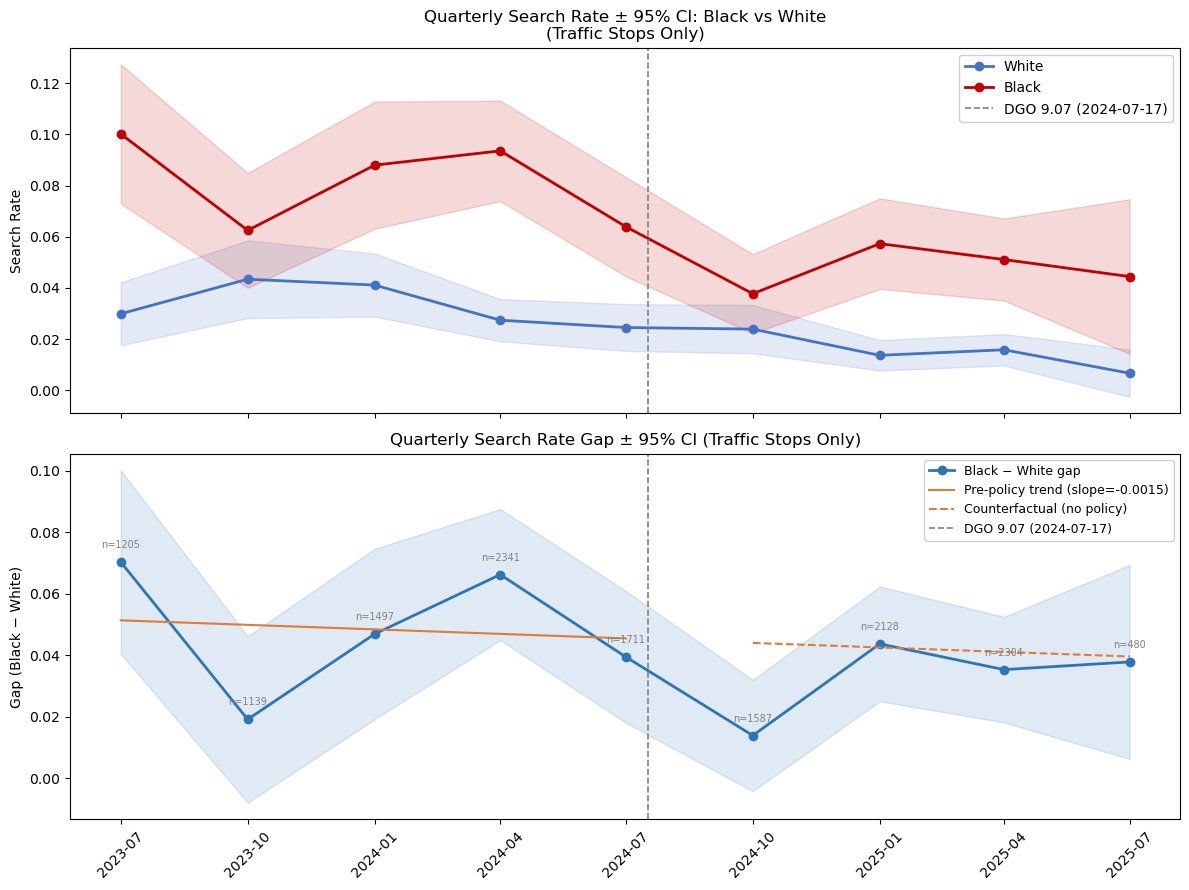


Parallel Trends Test (Traffic Stops, Pre 12m)
black:month_trend = 0.000310
p-value           = 0.8615
→ 平行趋势成立 ✓

Triple DID — All searches
post_DGO:traffic_stop:black = -0.062764,  p = 0.0008
95% CI: [-0.0995, -0.0260]
→ 显著：政策使 traffic stop 中 Black-White 差距减少

Triple DID — Consent search only
post_DGO:traffic_stop:black = -0.000229,  p = 0.9610
95% CI: [-0.0094, 0.0089]
→ 不显著


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

df = df[df["perceived_race_code"].isin([2, 7])].copy()
df["black"]        = (df["perceived_race_code"] == 2).astype(int)
df["traffic_stop"] = (df["reason_for_stop_code"] == 1).astype(int)
df["post_DGO"]     = (df["date"] >= policy_date).astype(int)
df["reason_1"]     = (df["reason_for_stop_code"] == 1).astype(int)

# 季度变量
df["quarter"] = df["date"].dt.to_period("Q").dt.to_timestamp()

# consent search
df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

# =========================
# 2. ±12 个月窗口
# =========================
start  = policy_date - pd.DateOffset(months=12)
end    = policy_date + pd.DateOffset(months=12)
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

# =========================
# 3. 季度平行趋势图（traffic stop 中 Black vs White）
# =========================
df_traffic = df_win[df_win["traffic_stop"] == 1].copy()

# 季度均值 + CI
qs = (
    df_traffic.groupby(["quarter", "black"])["searched"]
    .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
    .reset_index()
)
qs["ci95"] = qs["sem"] * 1.96

wide = qs.pivot(index="quarter", columns="black", values=["mean", "ci95", "n"])
wide.columns = ["_".join(map(str, c)) for c in wide.columns]
wide["gap_mean"] = wide["mean_1"] - wide["mean_0"]
wide["gap_ci"]   = np.sqrt(wide["ci95_1"]**2 + wide["ci95_0"]**2)

# pre期趋势线 + 延伸到post期（counterfactual）
pre_wide      = wide[wide.index < policy_date].copy()
pre_wide["t"] = np.arange(len(pre_wide))
z             = np.polyfit(pre_wide["t"], pre_wide["gap_mean"], 1)

# 延伸到全部时间点
wide["t"]         = np.arange(len(wide))
pre_end_t         = len(pre_wide) - 1
counterfactual    = np.polyval(z, wide["t"])

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ── 上图：Black vs White search rate ─────────────────────────
for col, label, color in [("mean_0", "White", "#4472C4"),
                           ("mean_1", "Black",  "#C00000")]:
    ci_col = col.replace("mean", "ci95")
    axes[0].plot(wide.index, wide[col], marker="o",
                 label=label, color=color, linewidth=2)
    axes[0].fill_between(wide.index,
                         wide[col] - wide[ci_col],
                         wide[col] + wide[ci_col],
                         alpha=0.15, color=color)

axes[0].axvline(policy_date, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[0].set_ylabel("Search Rate")
axes[0].set_title("Quarterly Search Rate ± 95% CI: Black vs White\n(Traffic Stops Only)")
axes[0].legend(framealpha=0.9)

# ── 下图：gap + counterfactual trend ─────────────────────────
axes[1].plot(wide.index, wide["gap_mean"], marker="o",
             color="#2E75B6", linewidth=2, label="Black − White gap")
axes[1].fill_between(wide.index,
                     wide["gap_mean"] - wide["gap_ci"],
                     wide["gap_mean"] + wide["gap_ci"],
                     alpha=0.15, color="#2E75B6")

# pre期实线，post期虚线（counterfactual）
pre_idx  = wide.index < policy_date
post_idx = wide.index >= policy_date

axes[1].plot(wide.index[pre_idx],  counterfactual[pre_idx],
             color="#E07B39", linewidth=1.5, linestyle="-",
             label=f"Pre-policy trend (slope={z[0]:.4f})")
axes[1].plot(wide.index[post_idx], counterfactual[post_idx],
             color="#E07B39", linewidth=1.5, linestyle="--",
             label="Counterfactual (no policy)")

axes[1].axvline(policy_date, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[1].set_ylabel("Gap (Black − White)")
axes[1].set_title("Quarterly Search Rate Gap ± 95% CI (Traffic Stops Only)")
axes[1].legend(framealpha=0.9, fontsize=9)

# 标注每个季度的样本量
for idx, row in wide.iterrows():
    n_b = int(row["n_1"]) if not np.isnan(row["n_1"]) else 0
    n_w = int(row["n_0"]) if not np.isnan(row["n_0"]) else 0
    axes[1].annotate(f"n={n_b+n_w}",
                     xy=(idx, wide.loc[idx, "gap_mean"]),
                     xytext=(0, 10), textcoords="offset points",
                     ha="center", fontsize=7, color="gray")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-Q%q" if False else "%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_parallel_trends_quarterly.png",
            dpi=150, bbox_inches="tight")
plt.show()

# =========================
# 4. 平行趋势检验（月度，traffic stop，政策前）
# =========================
pre_traffic = df_traffic[df_traffic["date"] < policy_date].copy()
pre_traffic["month_trend"] = (
    (pre_traffic["date"].dt.year  - pre_traffic["date"].dt.year.min()) * 12 +
    (pre_traffic["date"].dt.month - pre_traffic["date"].dt.month.min())
)

pt_model = smf.ols(
    "searched ~ black + month_trend + black:month_trend",
    data=pre_traffic
).fit(cov_type="HC1")

print("\n==============================")
print("Parallel Trends Test (Traffic Stops, Pre 12m)")
print("==============================")
print(f"black:month_trend = {pt_model.params['black:month_trend']:.6f}")
print(f"p-value           = {pt_model.pvalues['black:month_trend']:.4f}")
print("→ 平行趋势成立 ✓" if pt_model.pvalues["black:month_trend"] > 0.1
      else "→ 警告：平行趋势可能违背")

# =========================
# 5. Triple DID
# =========================
for outcome, label in [("searched", "All searches"),
                        ("consent_search", "Consent search only")]:
    did3 = smf.ols(
        f"{outcome} ~ post_DGO * traffic_stop * black"
        f" + low_visibility + C(district)",
        data=df_win
    ).fit(cov_type="HC1")

    key = "post_DGO:traffic_stop:black"
    print(f"\n==============================")
    print(f"Triple DID — {label}")
    print(f"==============================")
    print(f"{key} = {did3.params[key]:.6f},  p = {did3.pvalues[key]:.4f}")
    ci_lo = did3.conf_int().loc[key, 0]
    ci_hi = did3.conf_int().loc[key, 1]
    print(f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
    if did3.pvalues[key] < 0.05:
        d = "减少" if did3.params[key] < 0 else "增加"
        print(f"→ 显著：政策使 traffic stop 中 Black-White 差距{d}")
    else:
        print("→ 不显著")

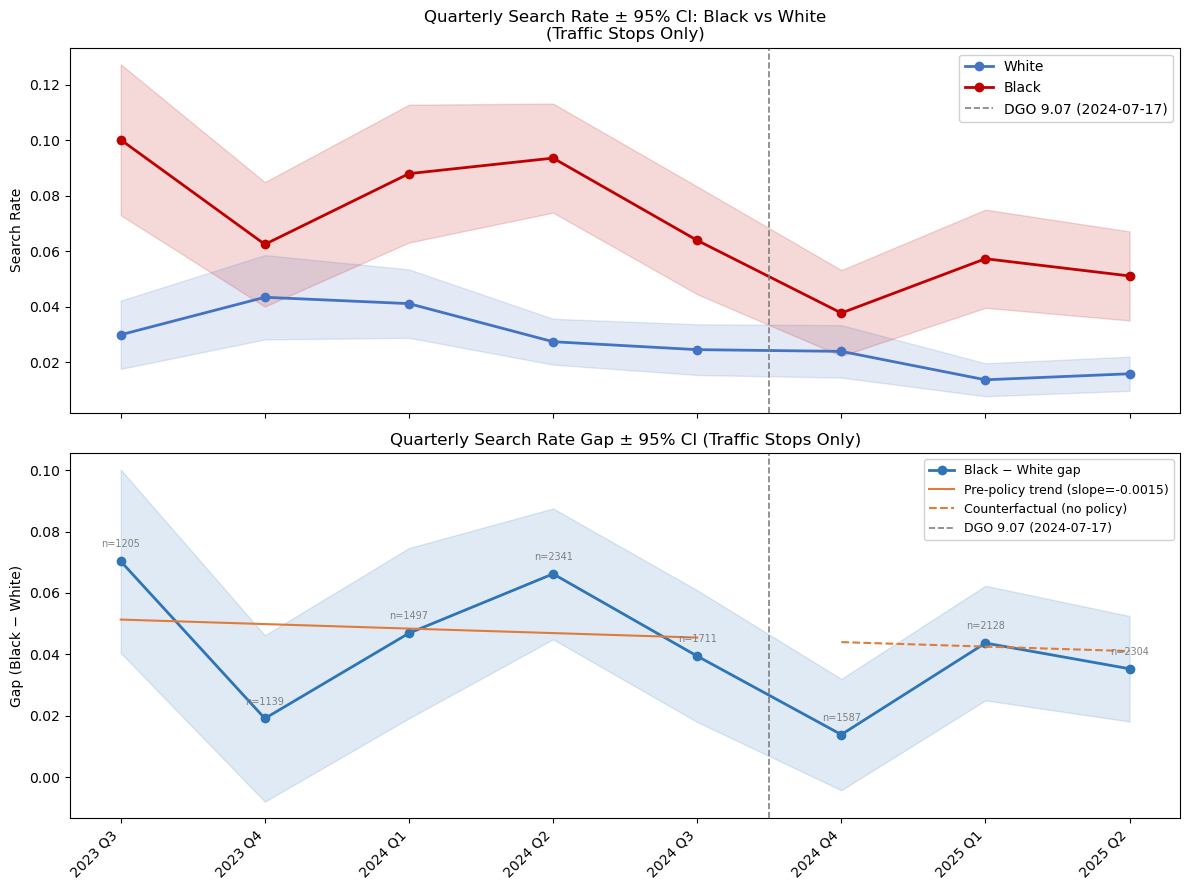


Parallel Trends Test (Traffic Stops, Pre 12m)
black:month_trend = 0.000310
p-value           = 0.8615
→ 平行趋势成立 ✓

Triple DID — All searches
post_DGO:traffic_stop:black = -0.055103
p-value = 0.0037
95% CI  = [-0.0924, -0.0179]
→ 显著：政策使 traffic stop 中 Black-White 差距减少

Triple DID — Consent search only
post_DGO:traffic_stop:black = 0.000883
p-value = 0.8528
95% CI  = [-0.0084, 0.0102]
→ 不显著


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

df = df[df["perceived_race_code"].isin([2, 7])].copy()
df["black"]        = (df["perceived_race_code"] == 2).astype(int)
df["traffic_stop"] = (df["reason_for_stop_code"] == 1).astype(int)
df["post_DGO"]     = (df["date"] >= policy_date).astype(int)
df["reason_1"]     = (df["reason_for_stop_code"] == 1).astype(int)
df["quarter"]      = df["date"].dt.to_period("Q").dt.to_timestamp()

df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

# =========================
# 2. 窗口：pre 12m + post 截至 2025-06（去掉不完整季度）
# =========================
start  = policy_date - pd.DateOffset(months=12)
end    = pd.Timestamp("2025-06-30")                # ← 改动1
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

# =========================
# 3. 季度平行趋势图（traffic stop 中 Black vs White）
# =========================
df_traffic = df_win[df_win["traffic_stop"] == 1].copy()

qs = (
    df_traffic.groupby(["quarter", "black"])["searched"]
    .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
    .reset_index()
)
qs["ci95"] = qs["sem"] * 1.96

wide = qs.pivot(index="quarter", columns="black", values=["mean", "ci95", "n"])
wide.columns = ["_".join(map(str, c)) for c in wide.columns]
wide["gap_mean"] = wide["mean_1"] - wide["mean_0"]
wide["gap_ci"]   = np.sqrt(wide["ci95_1"]**2 + wide["ci95_0"]**2)

# pre期趋势线 + counterfactual延伸
pre_wide      = wide[wide.index < policy_date].copy()
pre_wide["t"] = np.arange(len(pre_wide))
z             = np.polyfit(pre_wide["t"], pre_wide["gap_mean"], 1)
wide["t"]     = np.arange(len(wide))
counterfactual = np.polyval(z, wide["t"])

# 季度标签（2023 Q3 格式）← 改动2
def fmt_quarter(ts):
    q = (ts.month - 1) // 3 + 1
    return f"{ts.year} Q{q}"

x_labels = [fmt_quarter(ts) for ts in wide.index]

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
x = np.arange(len(wide))

# ── 上图 ─────────────────────────────────────────────────────
for col, label, color in [("mean_0", "White", "#4472C4"),
                           ("mean_1", "Black",  "#C00000")]:
    ci_col = col.replace("mean", "ci95")
    axes[0].plot(x, wide[col].values, marker="o",
                 label=label, color=color, linewidth=2)
    axes[0].fill_between(x,
                         (wide[col] - wide[ci_col]).values,
                         (wide[col] + wide[ci_col]).values,
                         alpha=0.15, color=color)

# 政策线（在pre最后一个点和post第一个点之间）
pre_n = len(pre_wide)
axes[0].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[0].set_ylabel("Search Rate")
axes[0].set_title("Quarterly Search Rate ± 95% CI: Black vs White\n(Traffic Stops Only)")
axes[0].legend(framealpha=0.9)

# ── 下图 ─────────────────────────────────────────────────────
axes[1].plot(x, wide["gap_mean"].values, marker="o",
             color="#2E75B6", linewidth=2, label="Black − White gap")
axes[1].fill_between(x,
                     (wide["gap_mean"] - wide["gap_ci"]).values,
                     (wide["gap_mean"] + wide["gap_ci"]).values,
                     alpha=0.15, color="#2E75B6")

pre_x  = x[:pre_n]
post_x = x[pre_n:]
axes[1].plot(pre_x,  counterfactual[:pre_n],
             color="#E07B39", linewidth=1.5, linestyle="-",
             label=f"Pre-policy trend (slope={z[0]:.4f})")
axes[1].plot(post_x, counterfactual[pre_n:],
             color="#E07B39", linewidth=1.5, linestyle="--",
             label="Counterfactual (no policy)")

axes[1].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[1].set_ylabel("Gap (Black − White)")
axes[1].set_title("Quarterly Search Rate Gap ± 95% CI (Traffic Stops Only)")
axes[1].legend(framealpha=0.9, fontsize=9)

# 标注样本量
for i, (idx, row) in enumerate(wide.iterrows()):
    n_total = int(row.get("n_1", 0) or 0) + int(row.get("n_0", 0) or 0)
    axes[1].annotate(f"n={n_total}",
                     xy=(i, wide["gap_mean"].iloc[i]),
                     xytext=(0, 10), textcoords="offset points",
                     ha="center", fontsize=7, color="gray")

# x轴季度标签
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_parallel_trends_quarterly.png",
            dpi=150, bbox_inches="tight")
plt.show()

# =========================
# 4. 平行趋势检验
# =========================
pre_traffic = df_traffic[df_traffic["date"] < policy_date].copy()
pre_traffic["month_trend"] = (
    (pre_traffic["date"].dt.year  - pre_traffic["date"].dt.year.min()) * 12 +
    (pre_traffic["date"].dt.month - pre_traffic["date"].dt.month.min())
)

pt_model = smf.ols(
    "searched ~ black + month_trend + black:month_trend",
    data=pre_traffic
).fit(cov_type="HC1")

print("\n==============================")
print("Parallel Trends Test (Traffic Stops, Pre 12m)")
print("==============================")
print(f"black:month_trend = {pt_model.params['black:month_trend']:.6f}")
print(f"p-value           = {pt_model.pvalues['black:month_trend']:.4f}")
print("→ 平行趋势成立 ✓" if pt_model.pvalues["black:month_trend"] > 0.1
      else "→ 警告：平行趋势可能违背")

# =========================
# 5. Triple DID
# =========================
for outcome, label in [("searched",       "All searches"),
                        ("consent_search", "Consent search only")]:
    did3 = smf.ols(
        f"{outcome} ~ post_DGO * traffic_stop * black"
        f" + low_visibility + C(district)",
        data=df_win
    ).fit(cov_type="HC1")

    key   = "post_DGO:traffic_stop:black"
    ci_lo = did3.conf_int().loc[key, 0]
    ci_hi = did3.conf_int().loc[key, 1]

    print(f"\n==============================")
    print(f"Triple DID — {label}")
    print(f"==============================")
    print(f"{key} = {did3.params[key]:.6f}")
    print(f"p-value = {did3.pvalues[key]:.4f}")
    print(f"95% CI  = [{ci_lo:.4f}, {ci_hi:.4f}]")
    if did3.pvalues[key] < 0.05:
        d = "减少" if did3.params[key] < 0 else "增加"
        print(f"→ 显著：政策使 traffic stop 中 Black-White 差距{d}")
    else:
        print("→ 不显著")

=== 样本概况（traffic stops only）===
Black stops: 32,938
White stops: 57,885
Search rate - Black: 0.149
Search rate - White: 0.036


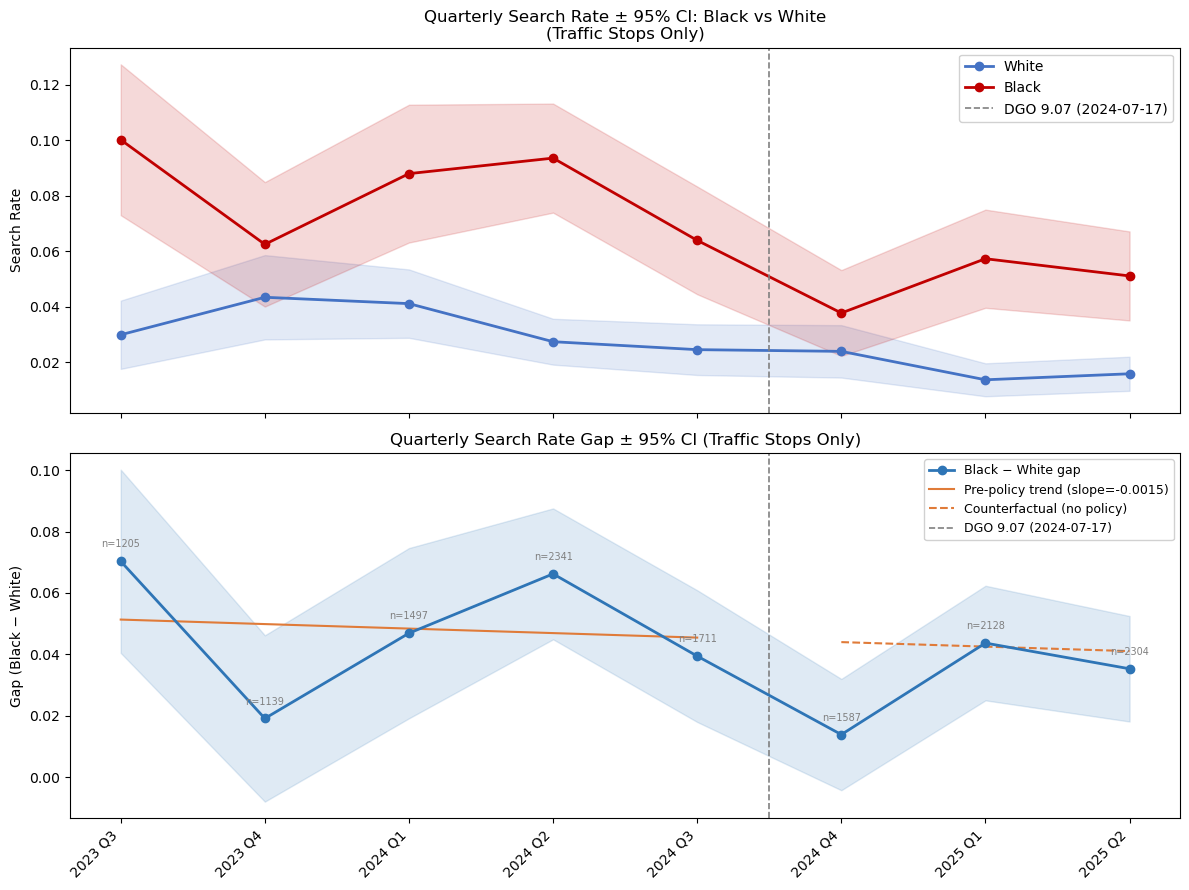


Parallel Trends Test (Traffic Stops, Pre 12m)
black:month_trend = 0.000310
p-value           = 0.8615
→ 平行趋势成立 ✓

DID — All searches (Traffic Stops Only)
                            OLS Regression Results                            
Dep. Variable:               searched   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     25.51
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.24e-66
Time:                        21:56:30   Log-Likelihood:                 2824.7
No. Observations:               12995   AIC:                            -5619.
Df Residuals:                   12980   BIC:                            -5507.
Df Model:                          14                                         
Covariance Type:                  HC1                                         
                                coef    std err        

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

# 只保留 traffic stop 中的 Black 和 White
df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()

df["black"]   = (df["perceived_race_code"] == 2).astype(int)
df["post_DGO"] = (df["date"] >= policy_date).astype(int)
df["quarter"]  = df["date"].dt.to_period("Q").dt.to_timestamp()

df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

print("=== 样本概况（traffic stops only）===")
print(f"Black stops: {df['black'].sum():,}")
print(f"White stops: {(df['black']==0).sum():,}")
print(f"Search rate - Black: {df[df['black']==1]['searched'].mean():.3f}")
print(f"Search rate - White: {df[df['black']==0]['searched'].mean():.3f}")

# =========================
# 2. 窗口：±12m，post 截至 2025-06
# =========================
start  = policy_date - pd.DateOffset(months=12)
end    = pd.Timestamp("2025-06-30")
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

# =========================
# 3. 季度平行趋势图
# =========================
qs = (
    df_win.groupby(["quarter", "black"])["searched"]
    .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
    .reset_index()
)
qs["ci95"] = qs["sem"] * 1.96

wide = qs.pivot(index="quarter", columns="black", values=["mean", "ci95", "n"])
wide.columns = ["_".join(map(str, c)) for c in wide.columns]
wide["gap_mean"] = wide["mean_1"] - wide["mean_0"]
wide["gap_ci"]   = np.sqrt(wide["ci95_1"]**2 + wide["ci95_0"]**2)

# pre期趋势线 + counterfactual
pre_wide      = wide[wide.index < policy_date].copy()
pre_wide["t"] = np.arange(len(pre_wide))
z             = np.polyfit(pre_wide["t"], pre_wide["gap_mean"], 1)
wide["t"]     = np.arange(len(wide))
counterfactual = np.polyval(z, wide["t"])
pre_n          = len(pre_wide)

# 季度标签
def fmt_q(ts):
    return f"{ts.year} Q{(ts.month-1)//3+1}"
x_labels = [fmt_q(ts) for ts in wide.index]
x        = np.arange(len(wide))

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ── 上图：Black vs White search rate ─────────────────────────
for col, label, color in [("mean_0", "White", "#4472C4"),
                           ("mean_1", "Black",  "#C00000")]:
    ci_col = col.replace("mean", "ci95")
    axes[0].plot(x, wide[col].values, marker="o",
                 label=label, color=color, linewidth=2)
    axes[0].fill_between(x,
                         (wide[col] - wide[ci_col]).values,
                         (wide[col] + wide[ci_col]).values,
                         alpha=0.15, color=color)

axes[0].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[0].set_ylabel("Search Rate")
axes[0].set_title("Quarterly Search Rate ± 95% CI: Black vs White\n(Traffic Stops Only)")
axes[0].legend(framealpha=0.9)

# ── 下图：gap + counterfactual ────────────────────────────────
axes[1].plot(x, wide["gap_mean"].values, marker="o",
             color="#2E75B6", linewidth=2, label="Black − White gap",
             zorder=3)
axes[1].fill_between(x,
                     (wide["gap_mean"] - wide["gap_ci"]).values,
                     (wide["gap_mean"] + wide["gap_ci"]).values,
                     alpha=0.15, color="#2E75B6")
axes[1].plot(x[:pre_n], counterfactual[:pre_n],
             color="#E07B39", linewidth=1.5, linestyle="-",
             label=f"Pre-policy trend (slope={z[0]:.4f})")
axes[1].plot(x[pre_n:], counterfactual[pre_n:],
             color="#E07B39", linewidth=1.5, linestyle="--",
             label="Counterfactual (no policy)")
axes[1].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[1].set_ylabel("Gap (Black − White)")
axes[1].set_title("Quarterly Search Rate Gap ± 95% CI (Traffic Stops Only)")
axes[1].legend(framealpha=0.9, fontsize=9)

# 样本量标注
for i, (_, row) in enumerate(wide.iterrows()):
    n = int(row.get("n_1", 0) or 0) + int(row.get("n_0", 0) or 0)
    axes[1].annotate(f"n={n}", xy=(i, wide["gap_mean"].iloc[i]),
                     xytext=(0, 10), textcoords="offset points",
                     ha="center", fontsize=7, color="gray")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_parallel_trends_quarterly.png",
            dpi=150, bbox_inches="tight")
plt.show()

# =========================
# 4. 平行趋势检验（政策前12个月）
# =========================
pre = df_win[df_win["date"] < policy_date].copy()
pre["month_trend"] = (
    (pre["date"].dt.year  - pre["date"].dt.year.min()) * 12 +
    (pre["date"].dt.month - pre["date"].dt.month.min())
)

pt = smf.ols(
    "searched ~ black + month_trend + black:month_trend",
    data=pre
).fit(cov_type="HC1")

print("\n==============================")
print("Parallel Trends Test (Traffic Stops, Pre 12m)")
print("==============================")
print(f"black:month_trend = {pt.params['black:month_trend']:.6f}")
print(f"p-value           = {pt.pvalues['black:month_trend']:.4f}")
print("→ 平行趋势成立 ✓" if pt.pvalues["black:month_trend"] > 0.1
      else "→ 警告：平行趋势可能违背")

# =========================
# 5. Standard DID（traffic stops only, Black vs White）
# =========================
for outcome, label in [("searched",       "All searches"),
                        ("consent_search", "Consent search only")]:
    did = smf.ols(
        f"{outcome} ~ post_DGO + black + post_DGO:black"
        f" + low_visibility + C(district)",
        data=df_win
    ).fit(cov_type="HC1")

    key   = "post_DGO:black"
    ci_lo = did.conf_int().loc[key, 0]
    ci_hi = did.conf_int().loc[key, 1]

    print(f"\n==============================")
    print(f"DID — {label} (Traffic Stops Only)")
    print(f"==============================")
    print(did.summary())
    print(f"\n{key} = {did.params[key]:.6f}")
    print(f"p-value = {did.pvalues[key]:.4f}")
    print(f"95% CI  = [{ci_lo:.4f}, {ci_hi:.4f}]")
    if did.pvalues[key] < 0.05:
        d = "减少" if did.params[key] < 0 else "增加"
        print(f"→ 显著：政策使 traffic stop 中 Black-White 搜查差距{d}")
    else:
        print("→ 不显著")

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 只看 traffic stop 中 Black 和 White
df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()
df["black"]   = (df["perceived_race_code"] == 2).astype(int)
df["quarter"] = df["date"].dt.to_period("Q").dt.to_timestamp()

# 聚焦 2023 Q3 和 2023 Q4
q3 = df[df["quarter"] == "2023-07-01"]
q4 = df[df["quarter"] == "2023-10-01"]

for label, sub in [("2023 Q3", q3), ("2023 Q4", q4)]:
    print(f"\n{'='*40}")
    print(f"{label}  (n={len(sub):,})")
    print(f"{'='*40}")

    for race, name in [(1, "Black"), (0, "White")]:
        g = sub[sub["black"] == race]
        print(f"\n  {name} (n={len(g):,})")
        print(f"    Search rate:        {g['searched'].mean():.4f}")
        print(f"    Consent search rate:{g['consent_search'].mean() if 'consent_search' in g else 'N/A'}")

    # district 分布有没有变化
    print(f"\n  District distribution (% of stops):")
    dist = sub.groupby(["district", "black"]).size().unstack(fill_value=0)
    dist.columns = ["White", "Black"]
    dist["Total"] = dist.sum(axis=1)
    dist["Black%"] = (dist["Black"] / dist["Total"] * 100).round(1)
    print(dist.sort_values("Total", ascending=False).to_string())

    # 按月细分
    print(f"\n  Monthly breakdown:")
    monthly = sub.groupby([sub["date"].dt.to_period("M"), "black"])["searched"].agg(["mean","count"])
    print(monthly.to_string())

# 对比：2023 Q4 Black的搜查率按district
print("\n" + "="*40)
print("2023 Q4 Black search rate by district")
print("="*40)
q4_black = q4[q4["black"] == 1]
print(q4_black.groupby("district")["searched"].agg(["mean","count"]).sort_values("mean", ascending=False).to_string())

print("\n" + "="*40)
print("2023 Q3 Black search rate by district")
print("="*40)
q3_black = q3[q3["black"] == 1]
print(q3_black.groupby("district")["searched"].agg(["mean","count"]).sort_values("mean", ascending=False).to_string())


2023 Q3  (n=1,416)

  Black (n=536)
    Search rate:        0.1045
    Consent search rate:N/A

  White (n=880)
    Search rate:        0.0307
    Consent search rate:N/A

  District distribution (% of stops):
            White  Black  Total  Black%
district                               
SOUTHERN      136    118    254    46.5
NORTHERN      110     61    171    35.7
TENDERLOIN     80     76    156    48.7
MISSION        94     61    155    39.4
RICHMOND      132     14    146     9.6
CENTRAL        57     41     98    41.8
TARAVAL        67     11     78    14.1
INGLESIDE      40     29     69    42.0
BAYVIEW        15     49     64    76.6
PARK           48      9     57    15.8
AIRPORT        27     12     39    30.8

  Monthly breakdown:
                   mean  count
date    black                 
2023-07 0      0.039146    281
        1      0.120000    150
2023-08 0      0.014337    279
        1      0.066667    180
2023-09 0      0.037500    320
        1      0.126214    206

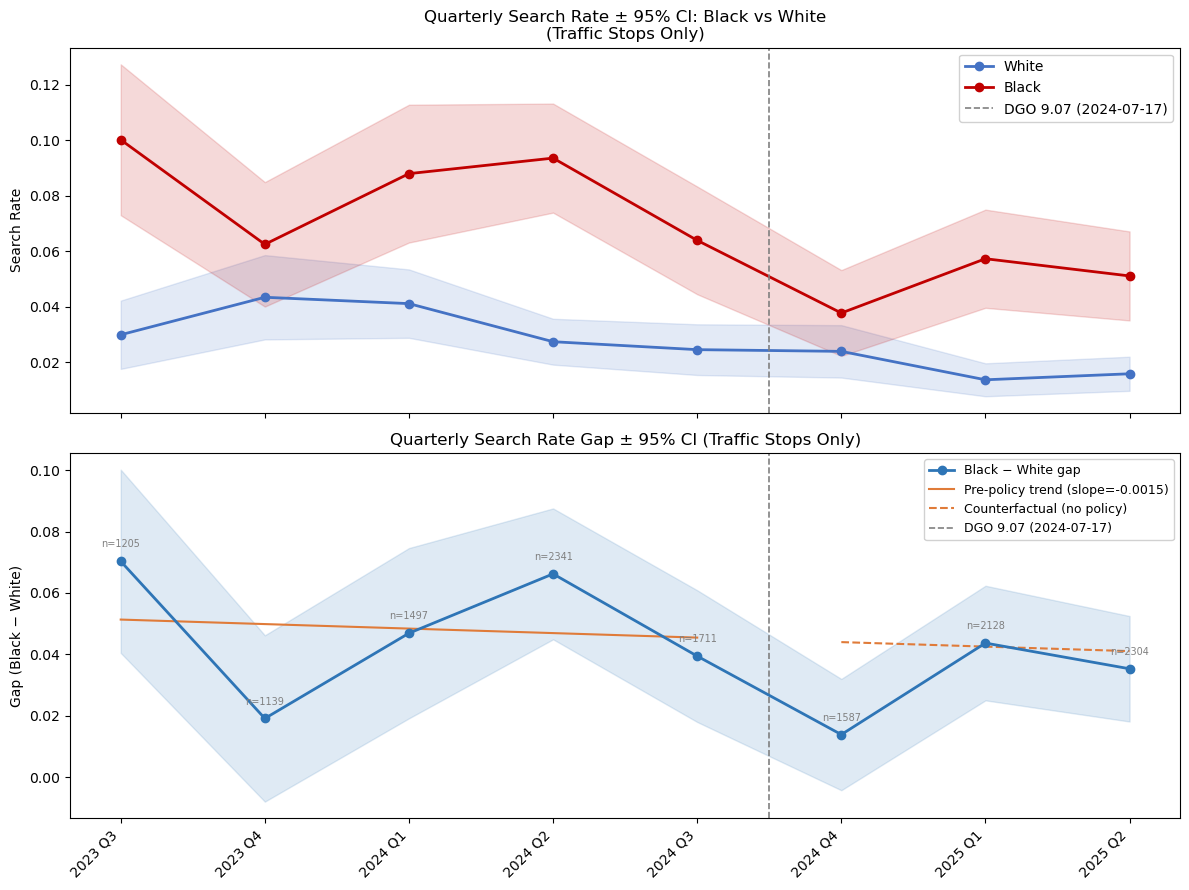


Parallel Trends Test — Basic
black:month_trend = 0.000310
p-value           = 0.8615
→ 平行趋势成立 ✓

Parallel Trends Test — With District × Trend
black:month_trend = -0.000287
p-value           = 0.8786
→ 平行趋势成立 ✓

DID Results Summary
Specification                                     Coef   p-val 95% CI
--------------------------------------------------------------------------------
Basic DID                                      -0.0163  0.0516*  [-0.0328, 0.0001]
DID + District × Trend                         -0.0115  0.1859  [-0.0285, 0.0055]

--- Full summary for main spec ---
                            OLS Regression Results                            
Dep. Variable:               searched   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     15.06
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.00e-63
Time:                

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

# 只保留 traffic stop 中的 Black 和 White
df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()

df["black"]    = (df["perceived_race_code"] == 2).astype(int)
df["post_DGO"] = (df["date"] >= policy_date).astype(int)
df["quarter"]  = df["date"].dt.to_period("Q").dt.to_timestamp()

df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

# =========================
# 2. 窗口：±12m，post 截至 2025-06
# =========================
start  = policy_date - pd.DateOffset(months=12)
end    = pd.Timestamp("2025-06-30")
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

# 线性时间趋势变量（用于 district × trend 交互）
df_win["month_trend"] = (
    (df_win["date"].dt.year  - df_win["date"].dt.year.min()) * 12 +
    (df_win["date"].dt.month - df_win["date"].dt.month.min())
)

# =========================
# 3. 季度平行趋势图
# =========================
qs = (
    df_win.groupby(["quarter", "black"])["searched"]
    .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
    .reset_index()
)
qs["ci95"] = qs["sem"] * 1.96

wide = qs.pivot(index="quarter", columns="black", values=["mean", "ci95", "n"])
wide.columns = ["_".join(map(str, c)) for c in wide.columns]
wide["gap_mean"] = wide["mean_1"] - wide["mean_0"]
wide["gap_ci"]   = np.sqrt(wide["ci95_1"]**2 + wide["ci95_0"]**2)

pre_wide      = wide[wide.index < policy_date].copy()
pre_wide["t"] = np.arange(len(pre_wide))
z             = np.polyfit(pre_wide["t"], pre_wide["gap_mean"], 1)
wide["t"]     = np.arange(len(wide))
counterfactual = np.polyval(z, wide["t"])
pre_n          = len(pre_wide)

def fmt_q(ts):
    return f"{ts.year} Q{(ts.month-1)//3+1}"
x_labels = [fmt_q(ts) for ts in wide.index]
x = np.arange(len(wide))

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for col, label, color in [("mean_0", "White", "#4472C4"),
                           ("mean_1", "Black",  "#C00000")]:
    ci_col = col.replace("mean", "ci95")
    axes[0].plot(x, wide[col].values, marker="o",
                 label=label, color=color, linewidth=2)
    axes[0].fill_between(x,
                         (wide[col] - wide[ci_col]).values,
                         (wide[col] + wide[ci_col]).values,
                         alpha=0.15, color=color)

axes[0].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[0].set_ylabel("Search Rate")
axes[0].set_title("Quarterly Search Rate ± 95% CI: Black vs White\n(Traffic Stops Only)")
axes[0].legend(framealpha=0.9)

axes[1].plot(x, wide["gap_mean"].values, marker="o",
             color="#2E75B6", linewidth=2, label="Black − White gap", zorder=3)
axes[1].fill_between(x,
                     (wide["gap_mean"] - wide["gap_ci"]).values,
                     (wide["gap_mean"] + wide["gap_ci"]).values,
                     alpha=0.15, color="#2E75B6")
axes[1].plot(x[:pre_n], counterfactual[:pre_n],
             color="#E07B39", linewidth=1.5, linestyle="-",
             label=f"Pre-policy trend (slope={z[0]:.4f})")
axes[1].plot(x[pre_n:], counterfactual[pre_n:],
             color="#E07B39", linewidth=1.5, linestyle="--",
             label="Counterfactual (no policy)")
axes[1].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (2024-07-17)")
axes[1].set_ylabel("Gap (Black − White)")
axes[1].set_title("Quarterly Search Rate Gap ± 95% CI (Traffic Stops Only)")
axes[1].legend(framealpha=0.9, fontsize=9)

for i, (_, row) in enumerate(wide.iterrows()):
    n = int(row.get("n_1", 0) or 0) + int(row.get("n_0", 0) or 0)
    axes[1].annotate(f"n={n}", xy=(i, wide["gap_mean"].iloc[i]),
                     xytext=(0, 10), textcoords="offset points",
                     ha="center", fontsize=7, color="gray")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_parallel_trends_quarterly.png",
            dpi=150, bbox_inches="tight")
plt.show()

# =========================
# 4. 平行趋势检验（加 district × month_trend 控制）
# =========================
pre = df_win[df_win["date"] < policy_date].copy()
pre["month_trend"] = (
    (pre["date"].dt.year  - pre["date"].dt.year.min()) * 12 +
    (pre["date"].dt.month - pre["date"].dt.month.min())
)

# 基础版（不含district趋势）
pt_base = smf.ols(
    "searched ~ black + month_trend + black:month_trend",
    data=pre
).fit(cov_type="HC1")

# 升级版（控制district各自的时间趋势）
pt_full = smf.ols(
    "searched ~ black + month_trend + black:month_trend"
    " + C(district):month_trend",
    data=pre
).fit(cov_type="HC1")

print("\n==============================")
print("Parallel Trends Test — Basic")
print("==============================")
print(f"black:month_trend = {pt_base.params['black:month_trend']:.6f}")
print(f"p-value           = {pt_base.pvalues['black:month_trend']:.4f}")
print("→ 平行趋势成立 ✓" if pt_base.pvalues["black:month_trend"] > 0.1
      else "→ 警告：可能违背")

print("\n==============================")
print("Parallel Trends Test — With District × Trend")
print("==============================")
print(f"black:month_trend = {pt_full.params['black:month_trend']:.6f}")
print(f"p-value           = {pt_full.pvalues['black:month_trend']:.4f}")
print("→ 平行趋势成立 ✓" if pt_full.pvalues["black:month_trend"] > 0.1
      else "→ 警告：可能违背")

# =========================
# 5. DID — 三个版本对比
# =========================
specs = [
    # (名称, 公式)
    ("Basic DID",
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district)"),

    ("DID + District × Trend",
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(district):month_trend"),

    ("DID + District × Trend (consent search)",
     "consent_search ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(district):month_trend"),
]

key = "post_DGO:black"
print("\n" + "="*50)
print("DID Results Summary")
print("="*50)
print(f"{'Specification':<45} {'Coef':>8} {'p-val':>7} {'95% CI'}")
print("-"*80)

for name, formula in specs:
    outcome = "consent_search" if "consent" in name else "searched"
    model = smf.ols(formula, data=df_win).fit(cov_type="HC1")
    coef  = model.params[key]
    pval  = model.pvalues[key]
    ci_lo = model.conf_int().loc[key, 0]
    ci_hi = model.conf_int().loc[key, 1]
    sig   = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
    print(f"{name:<45} {coef:>8.4f} {pval:>7.4f}{sig}  [{ci_lo:.4f}, {ci_hi:.4f}]")
    if name == "DID + District × Trend":
        print("\n--- Full summary for main spec ---")
        print(model.summary())
        print("---\n")

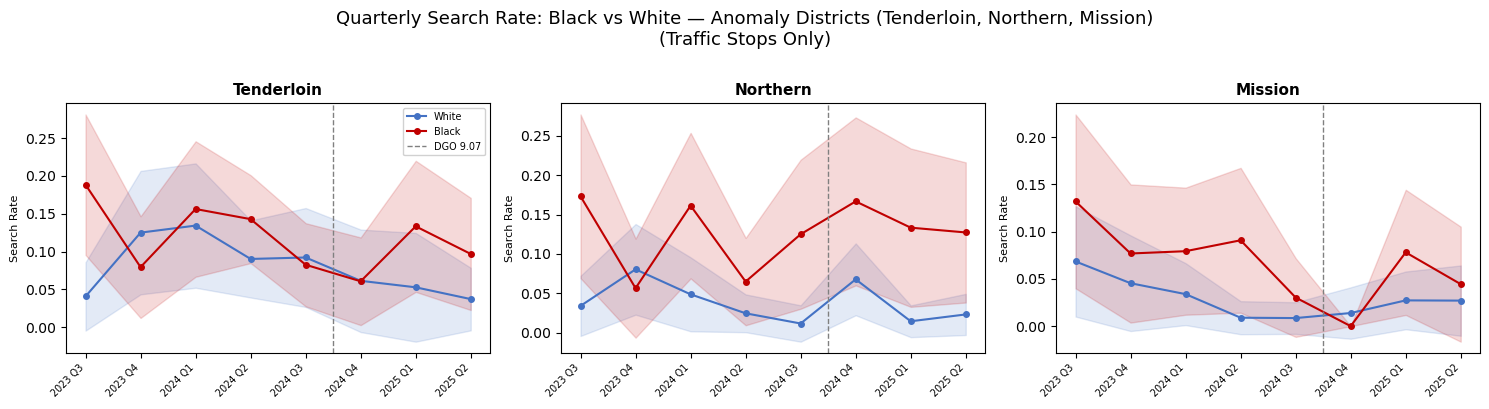

Saved: /Users/thisisjasmine/Desktop/ECO225/fig_districts_anomaly.png


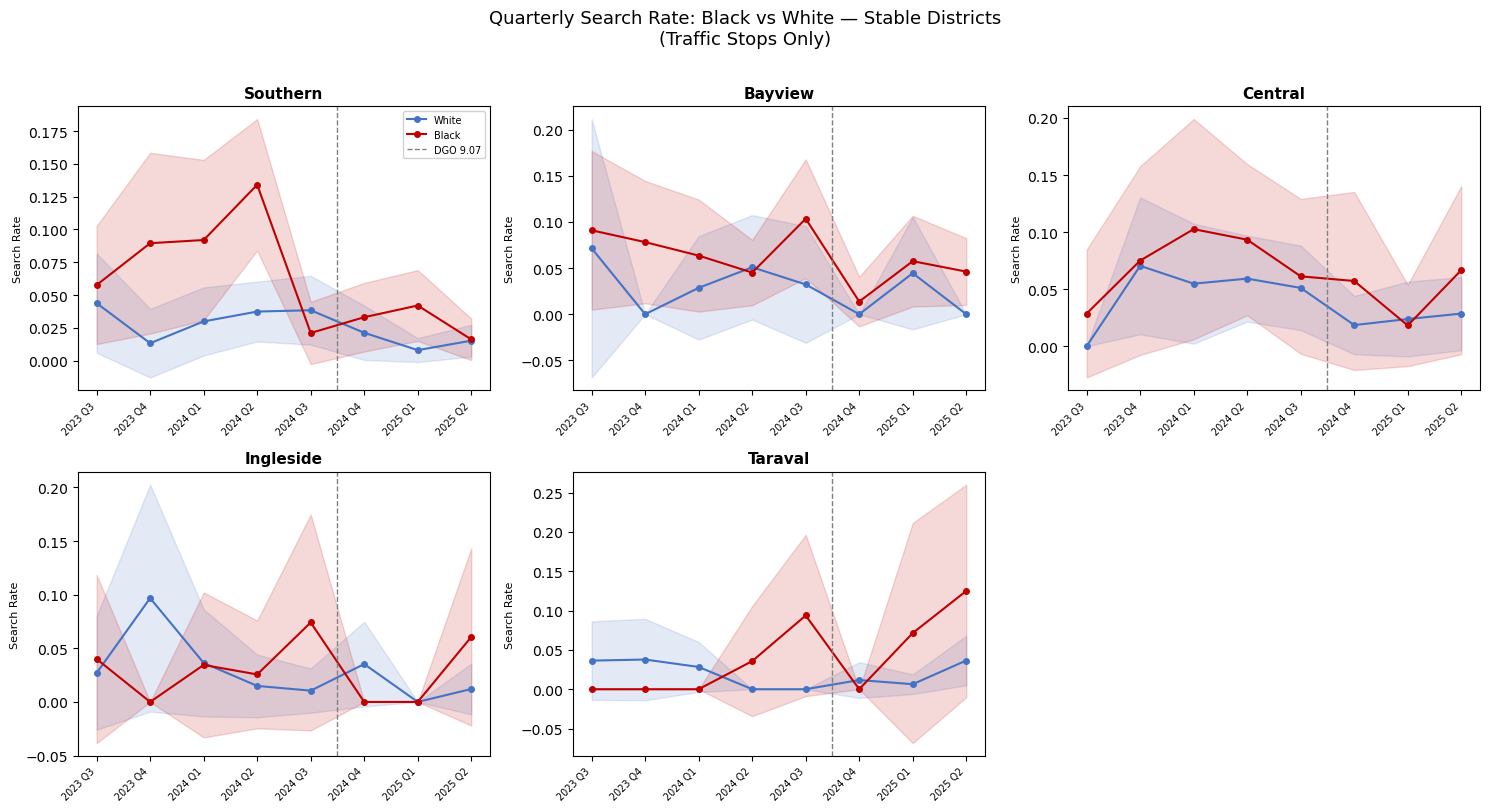

Saved: /Users/thisisjasmine/Desktop/ECO225/fig_districts_stable.png

Parallel Trends — Anomaly Districts
  TENDERLOIN   black:trend p = 0.3067 ✓
  NORTHERN     black:trend p = 0.2560 ✓
  MISSION      black:trend p = 0.9700 ✓

Parallel Trends — Stable Districts
  SOUTHERN     black:trend p = 0.2313 ✓
  BAYVIEW      black:trend p = 0.8460 ✓
  CENTRAL      black:trend p = 0.4864 ✓
  INGLESIDE    black:trend p = 0.1926 ✓
  TARAVAL      black:trend p = 0.0479 ✗

DID Results by District Group
Group                              Coef   p-val  95% CI
-----------------------------------------------------------------
Anomaly districts                0.0008 0.9669  [-0.0351, 0.0366]
Stable districts                -0.0137 0.1997  [-0.0347, 0.0072]
All districts                   -0.0113 0.2293  [-0.0297, 0.0071]


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()

df["black"]    = (df["perceived_race_code"] == 2).astype(int)
df["post_DGO"] = (df["date"] >= policy_date).astype(int)
df["quarter"]  = df["date"].dt.to_period("Q").dt.to_timestamp()
df["month_trend"] = (
    (df["date"].dt.year  - df["date"].dt.year.min()) * 12 +
    (df["date"].dt.month - df["date"].dt.month.min())
)
df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

# =========================
# 2. 窗口
# =========================
start  = policy_date - pd.DateOffset(months=12)
end    = pd.Timestamp("2025-06-30")
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

# =========================
# 3. 分district画季度平行趋势图
#    两组：异常district vs 稳定district
# =========================
anomaly_districts = ["TENDERLOIN", "NORTHERN", "MISSION"]
stable_districts  = ["SOUTHERN", "BAYVIEW", "CENTRAL", "INGLESIDE", "TARAVAL"]

def fmt_q(ts):
    return f"{ts.year} Q{(ts.month-1)//3+1}"

def plot_district_group(df_sub, districts, group_label, save_path, ncols=3):
    nrows = int(np.ceil(len(districts) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 4 * nrows),
                             sharey=False)
    axes = axes.flatten()

    for idx, dist in enumerate(districts):
        ax  = axes[idx]
        sub = df_sub[df_sub["district"] == dist]

        if len(sub) == 0:
            ax.set_visible(False)
            continue

        qs = (
            sub.groupby(["quarter", "black"])["searched"]
            .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
            .reset_index()
        )
        qs["ci95"] = qs["sem"] * 1.96

        try:
            wide = qs.pivot(index="quarter", columns="black",
                            values=["mean", "ci95", "n"])
            wide.columns = ["_".join(map(str, c)) for c in wide.columns]
        except Exception:
            ax.set_title(f"{dist} (insufficient data)")
            continue

        x        = np.arange(len(wide))
        x_labels = [fmt_q(ts) for ts in wide.index]
        pre_n    = len(wide[wide.index < policy_date])

        for col, label, color in [("mean_0", "White", "#4472C4"),
                                   ("mean_1", "Black",  "#C00000")]:
            if col not in wide.columns:
                continue
            ci_col = col.replace("mean", "ci95")
            ax.plot(x, wide[col].values, marker="o",
                    label=label, color=color, linewidth=1.5, markersize=4)
            if ci_col in wide.columns:
                ax.fill_between(x,
                                (wide[col] - wide[ci_col]).values,
                                (wide[col] + wide[ci_col]).values,
                                alpha=0.15, color=color)

        ax.axvline(pre_n - 0.5, color="gray", linestyle="--",
                   linewidth=1, label="DGO 9.07")
        ax.set_title(dist.title(), fontsize=11, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=7)
        ax.set_ylabel("Search Rate", fontsize=8)
        if idx == 0:
            ax.legend(fontsize=7, framealpha=0.9)

    # 隐藏多余的subplot
    for i in range(len(districts), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle(f"Quarterly Search Rate: Black vs White — {group_label}\n"
                 f"(Traffic Stops Only)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

BASE = "/Users/thisisjasmine/Desktop/ECO225/"

# 异常district
plot_district_group(df_win, anomaly_districts,
                    "Anomaly Districts (Tenderloin, Northern, Mission)",
                    BASE + "fig_districts_anomaly.png", ncols=3)

# 稳定district
plot_district_group(df_win, stable_districts,
                    "Stable Districts",
                    BASE + "fig_districts_stable.png", ncols=3)

# =========================
# 4. 平行趋势检验：分两组 district
# =========================
print("\n==============================")
print("Parallel Trends — Anomaly Districts")
print("==============================")
for dist in anomaly_districts:
    pre_d = df_win[
        (df_win["date"] < policy_date) &
        (df_win["district"] == dist)
    ].copy()
    pre_d["mt"] = (
        (pre_d["date"].dt.year  - pre_d["date"].dt.year.min()) * 12 +
        (pre_d["date"].dt.month - pre_d["date"].dt.month.min())
    )
    if len(pre_d) < 50:
        print(f"{dist}: insufficient data")
        continue
    try:
        pt = smf.ols("searched ~ black + mt + black:mt",
                     data=pre_d).fit(cov_type="HC1")
        p  = pt.pvalues["black:mt"]
        print(f"  {dist:<12} black:trend p = {p:.4f} "
              f"{'✓' if p > 0.1 else '✗'}")
    except Exception as e:
        print(f"  {dist}: {e}")

print("\n==============================")
print("Parallel Trends — Stable Districts")
print("==============================")
for dist in stable_districts:
    pre_d = df_win[
        (df_win["date"] < policy_date) &
        (df_win["district"] == dist)
    ].copy()
    pre_d["mt"] = (
        (pre_d["date"].dt.year  - pre_d["date"].dt.year.min()) * 12 +
        (pre_d["date"].dt.month - pre_d["date"].dt.month.min())
    )
    if len(pre_d) < 50:
        print(f"{dist}: insufficient data")
        continue
    try:
        pt = smf.ols("searched ~ black + mt + black:mt",
                     data=pre_d).fit(cov_type="HC1")
        p  = pt.pvalues["black:mt"]
        print(f"  {dist:<12} black:trend p = {p:.4f} "
              f"{'✓' if p > 0.1 else '✗'}")
    except Exception as e:
        print(f"  {dist}: {e}")

# =========================
# 5. DID 分组对比
# =========================
key = "post_DGO:black"
print("\n" + "="*60)
print("DID Results by District Group")
print("="*60)
print(f"{'Group':<30} {'Coef':>8} {'p-val':>7}  95% CI")
print("-"*65)

for label, districts in [
    ("Anomaly districts",  anomaly_districts),
    ("Stable districts",   stable_districts),
    ("All districts",      anomaly_districts + stable_districts),
]:
    sub = df_win[df_win["district"].isin(districts)]
    try:
        m = smf.ols(
            "searched ~ post_DGO + black + post_DGO:black"
            " + low_visibility + C(district) + C(district):month_trend",
            data=sub
        ).fit(cov_type="HC1")
        c  = m.params[key]
        p  = m.pvalues[key]
        lo = m.conf_int().loc[key, 0]
        hi = m.conf_int().loc[key, 1]
        sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
        print(f"{label:<30} {c:>8.4f} {p:>6.4f}{sig}  [{lo:.4f}, {hi:.4f}]")
    except Exception as e:
        print(f"{label}: error — {e}")

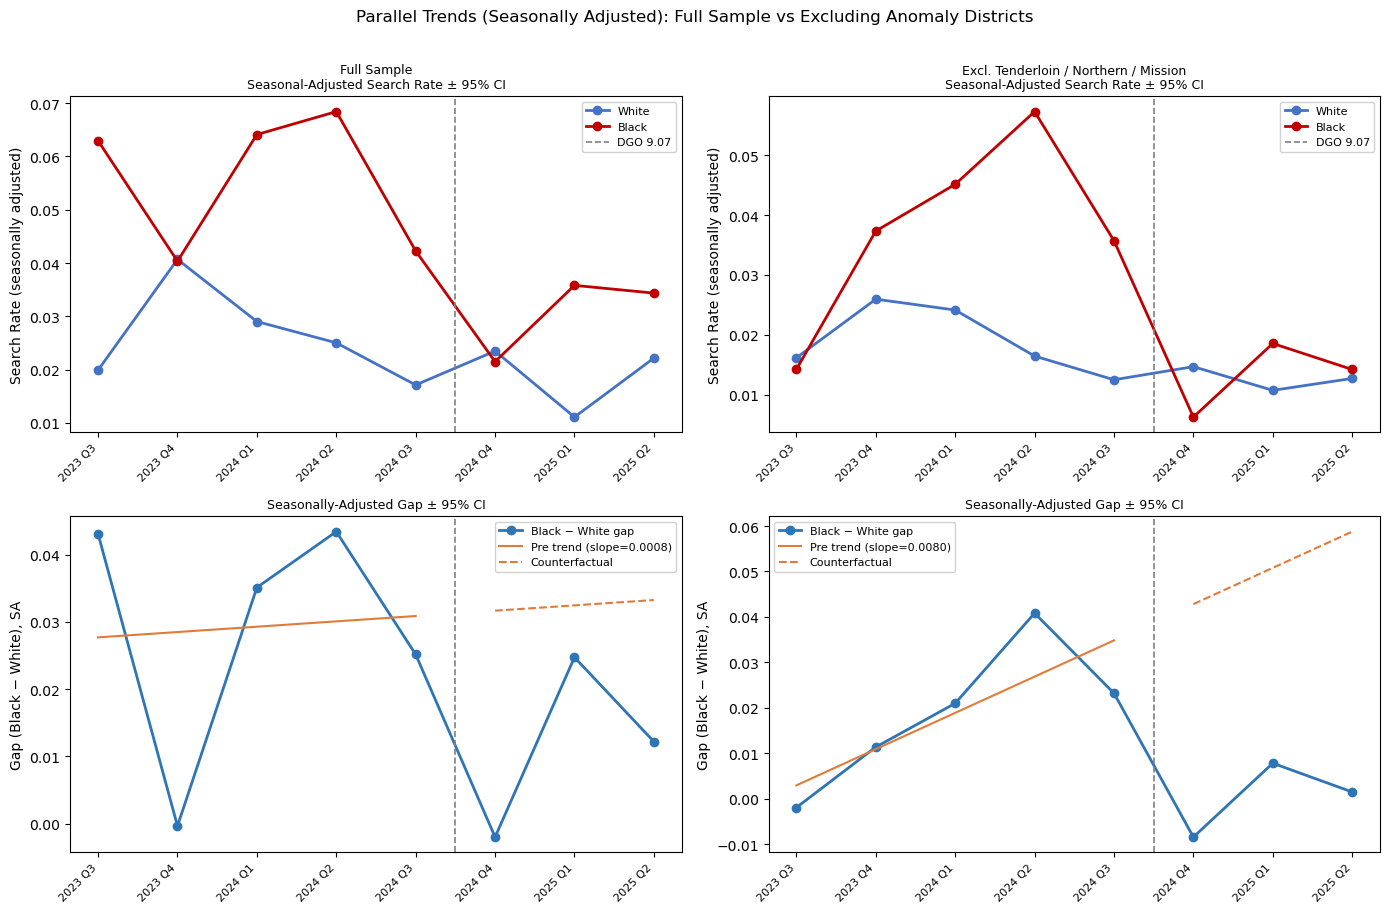


Parallel Trends Test (with Quarter FE)
  [Full sample          ] black:month_trend = 0.000295,  p = 0.8682 ✓
  [Excl. anomaly dist.  ] black:month_trend = 0.002751,  p = 0.1628 ✓

Robustness Check: DID Results (with Quarter FE)
Specification                                 N     Coef       p  95% CI
--------------------------------------------------------------------------------
(1) Basic DID                             13912  -0.0163 0.0516*  [-0.0328, 0.0001]
(2) + Quarter FE                          13912  -0.0161 0.0544*  [-0.0326, 0.0003]
(3) + Quarter FE + Dist×Trend             13912  -0.0113 0.1947    [-0.0283, 0.0058]
(4) Excl. anomaly + Quarter FE            10209  -0.0202 0.0277**  [-0.0382, -0.0022]
(5) Excl. + QFE + Dist×Trend              10209  -0.0143 0.1360    [-0.0330, 0.0045]
(6) Consent search + QFE                  13912  -0.0002 0.9150    [-0.0048, 0.0043]


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()

df["black"]         = (df["perceived_race_code"] == 2).astype(int)
df["post_DGO"]      = (df["date"] >= policy_date).astype(int)
df["quarter"]       = df["date"].dt.to_period("Q").dt.to_timestamp()
df["quarter_of_year"] = df["date"].dt.quarter          # 1/2/3/4 季节FE用
df["month_trend"]   = (
    (df["date"].dt.year  - df["date"].dt.year.min()) * 12 +
    (df["date"].dt.month - df["date"].dt.month.min())
)
df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

# =========================
# 2. 窗口 + 两个样本
# =========================
start  = policy_date - pd.DateOffset(months=12)
end    = pd.Timestamp("2025-06-30")
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

anomaly    = ["TENDERLOIN", "NORTHERN", "MISSION"]
df_full    = df_win.copy()
df_excl    = df_win[~df_win["district"].isin(anomaly)].copy()

# =========================
# 3. Seasonally-adjusted 平行趋势图
#    先用 pre 期拟合季节效应，扣掉后画图
# =========================
def make_seasonal_resid(df_sub):
    """扣掉季度固定效应（Q1/Q2/Q3/Q4）和district FE，保留种族和时间信息"""
    pre = df_sub[df_sub["date"] < policy_date].copy()
    m   = smf.ols(
        "searched ~ C(quarter_of_year) + C(district) + low_visibility",
        data=pre
    ).fit()
    df_sub = df_sub.copy()
    df_sub["searched_sa"] = df_sub["searched"] - m.predict(df_sub)
    df_sub["searched_sa"] += df_sub["searched"].mean()   # 加回均值保持scale
    return df_sub

df_full_sa = make_seasonal_resid(df_full)
df_excl_sa = make_seasonal_resid(df_excl)

def compute_wide(df_sub, outcome="searched_sa"):
    qs = (
        df_sub.groupby(["quarter", "black"])[outcome]
        .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
        .reset_index()
    )
    qs["ci95"] = qs["sem"] * 1.96
    wide = qs.pivot(index="quarter", columns="black",
                    values=["mean", "ci95", "n"])
    wide.columns = ["_".join(map(str, c)) for c in wide.columns]
    wide["gap_mean"] = wide["mean_1"] - wide["mean_0"]
    wide["gap_ci"]   = np.sqrt(wide["ci95_1"]**2 + wide["ci95_0"]**2)
    return wide

def fmt_q(ts):
    return f"{ts.year} Q{(ts.month-1)//3+1}"

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col_idx, (df_sa, title) in enumerate([
    (df_full_sa, "Full Sample"),
    (df_excl_sa, "Excl. Tenderloin / Northern / Mission"),
]):
    wide  = compute_wide(df_sa)
    x     = np.arange(len(wide))
    pre_n = len(wide[wide.index < policy_date])
    x_labels = [fmt_q(ts) for ts in wide.index]

    # 上行：Black vs White
    ax0 = axes[0][col_idx]
    for col, label, color in [("mean_0", "White", "#4472C4"),
                               ("mean_1", "Black",  "#C00000")]:
        ci_col = col.replace("mean", "ci95")
        ax0.plot(x, wide[col].values, marker="o",
                 label=label, color=color, linewidth=2)
        ax0.fill_between(x,
                         (wide[col] - wide[ci_col]).values,
                         (wide[col] + wide[ci_col]).values,
                         alpha=0.15, color=color)
    ax0.axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07")
    ax0.set_title(f"{title}\nSeasonal-Adjusted Search Rate ± 95% CI",
                  fontsize=9)
    ax0.set_ylabel("Search Rate (seasonally adjusted)")
    ax0.legend(fontsize=8, framealpha=0.9)
    ax0.set_xticks(x)
    ax0.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)

    # 下行：gap
    ax1 = axes[1][col_idx]
    pre_wide      = wide[wide.index < policy_date].copy()
    pre_wide["t"] = np.arange(len(pre_wide))
    z             = np.polyfit(pre_wide["t"], pre_wide["gap_mean"], 1)
    wide["t"]     = np.arange(len(wide))
    cf            = np.polyval(z, wide["t"])

    ax1.plot(x, wide["gap_mean"].values, marker="o",
             color="#2E75B6", linewidth=2, label="Black − White gap")
    ax1.fill_between(x,
                     (wide["gap_mean"] - wide["gap_ci"]).values,
                     (wide["gap_mean"] + wide["gap_ci"]).values,
                     alpha=0.15, color="#2E75B6")
    ax1.plot(x[:pre_n], cf[:pre_n],
             color="#E07B39", linewidth=1.5, linestyle="-",
             label=f"Pre trend (slope={z[0]:.4f})")
    ax1.plot(x[pre_n:], cf[pre_n:],
             color="#E07B39", linewidth=1.5, linestyle="--",
             label="Counterfactual")
    ax1.axvline(pre_n - 0.5, color="gray", linestyle="--", linewidth=1.2)
    ax1.set_title("Seasonally-Adjusted Gap ± 95% CI", fontsize=9)
    ax1.set_ylabel("Gap (Black − White), SA")
    ax1.legend(fontsize=8, framealpha=0.9)
    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)

plt.suptitle("Parallel Trends (Seasonally Adjusted): "
             "Full Sample vs Excluding Anomaly Districts",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_parallel_trends_SA.png",
            dpi=150, bbox_inches="tight")
plt.show()

# =========================
# 4. 平行趋势检验（加季度FE）
# =========================
def pt_test(df_sub, label):
    pre = df_sub[df_sub["date"] < policy_date].copy()
    pre["mt"] = (
        (pre["date"].dt.year  - pre["date"].dt.year.min()) * 12 +
        (pre["date"].dt.month - pre["date"].dt.month.min())
    )
    m = smf.ols(
        "searched ~ black + mt + black:mt + C(quarter_of_year)",
        data=pre
    ).fit(cov_type="HC1")
    p = m.pvalues["black:mt"]
    c = m.params["black:mt"]
    print(f"  [{label}] black:month_trend = {c:.6f},  p = {p:.4f} "
          f"{'✓' if p > 0.1 else '✗'}")

print("\n==============================")
print("Parallel Trends Test (with Quarter FE)")
print("==============================")
pt_test(df_full, "Full sample          ")
pt_test(df_excl, "Excl. anomaly dist.  ")

# =========================
# 5. Robustness table（加季度FE）
# =========================
key = "post_DGO:black"

specs = [
    ("(1) Basic DID",                   "searched",       df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district)"),

    ("(2) + Quarter FE",                "searched",       df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),

    ("(3) + Quarter FE + Dist×Trend",   "searched",       df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + C(district):month_trend"),

    ("(4) Excl. anomaly + Quarter FE",  "searched",       df_excl,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),

    ("(5) Excl. + QFE + Dist×Trend",    "searched",       df_excl,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + C(district):month_trend"),

    ("(6) Consent search + QFE",        "consent_search", df_full,
     "consent_search ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),
]

print("\n" + "="*80)
print("Robustness Check: DID Results (with Quarter FE)")
print("="*80)
print(f"{'Specification':<40} {'N':>6} {'Coef':>8} {'p':>7}  95% CI")
print("-"*80)

for name, outcome, df_use, formula in specs:
    try:
        m    = smf.ols(formula, data=df_use).fit(cov_type="HC1")
        c    = m.params[key]
        p    = m.pvalues[key]
        lo   = m.conf_int().loc[key, 0]
        hi   = m.conf_int().loc[key, 1]
        sig  = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else "  "
        print(f"{name:<40} {len(df_use):>6} {c:>8.4f} {p:>6.4f}{sig}"
              f"  [{lo:.4f}, {hi:.4f}]")
    except Exception as e:
        print(f"{name}: error — {e}")

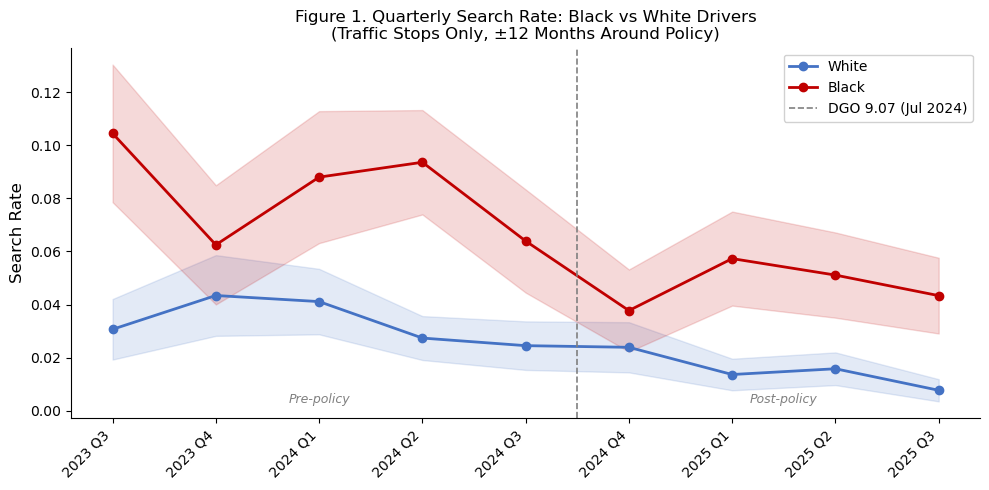

Saved: fig1_main_parallel_trends.png


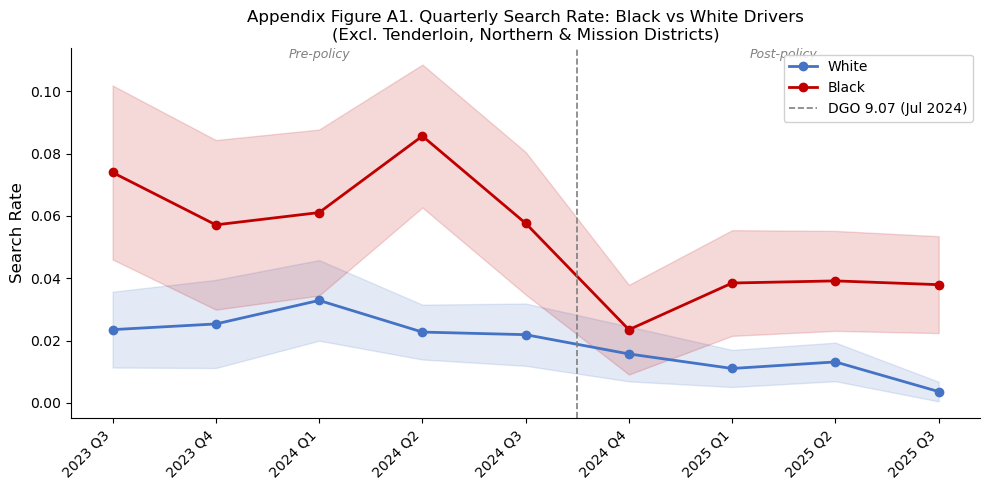

Saved: figA1_appendix_excl_anomaly.png

Parallel Trends Test
  [Full sample          ] black:month_trend = -0.000336,  p = 0.8453 ✓
  [Excl. anomaly dist.  ] black:month_trend = 0.001448,  p = 0.4631 ✓

Table 2. Robustness Check: Effect of DGO 9.07 on Black-White Search Gap
Specification                                 N     Coef       p  95% CI
--------------------------------------------------------------------------------
(1) Basic DID                             16592  -0.0180 0.0228**  [-0.0335, -0.0025]
(2) + Quarter FE                          16592  -0.0179 0.0233**  [-0.0334, -0.0024]
(3) + QFE + Dist×Trend                    16592  -0.0122 0.1330    [-0.0282, 0.0037]
(4) Excl. anomaly + QFE                   12318  -0.0210 0.0175**  [-0.0383, -0.0037]
(5) Excl. + QFE + Dist×Trend              12318  -0.0141 0.1234    [-0.0320, 0.0038]
(6) Consent search + QFE                  16592  -0.0015 0.4867    [-0.0057, 0.0027]

Note: * p<0.1, ** p<0.05, *** p<0.01. HC1 robust SE.
Outc

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()

df["black"]    = (df["perceived_race_code"] == 2).astype(int)
df["post_DGO"] = (df["date"] >= policy_date).astype(int)
df["quarter"]  = df["date"].dt.to_period("Q").dt.to_timestamp()
df["month_trend"] = (
    (df["date"].dt.year  - df["date"].dt.year.min()) * 12 +
    (df["date"].dt.month - df["date"].dt.month.min())
)
df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

start = pd.Timestamp("2023-06-30")
end   = pd.Timestamp("2025-09-30")

df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

anomaly = ["TENDERLOIN", "NORTHERN", "MISSION"]
df_full = df_win.copy()
df_excl = df_win[~df_win["district"].isin(anomaly)].copy()

def fmt_q(ts):
    return f"{ts.year} Q{(ts.month-1)//3+1}"

def compute_wide(df_sub):
    qs = (
        df_sub.groupby(["quarter", "black"])["searched"]
        .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
        .reset_index()
    )
    qs["ci95"] = qs["sem"] * 1.96
    wide = qs.pivot(index="quarter", columns="black",
                    values=["mean", "ci95", "n"])
    wide.columns = ["_".join(map(str, c)) for c in wide.columns]
    return wide

BASE = "/Users/thisisjasmine/Desktop/ECO225/"

# =========================
# 图1（正文）：Full sample，只画 Black vs White
# =========================
wide = compute_wide(df_full)
x    = np.arange(len(wide))
pre_n = len(wide[wide.index < policy_date])
x_labels = [fmt_q(ts) for ts in wide.index]

fig, ax = plt.subplots(figsize=(10, 5))

for col, label, color in [("mean_0", "White", "#4472C4"),
                           ("mean_1", "Black",  "#C00000")]:
    ci_col = col.replace("mean", "ci95")
    ax.plot(x, wide[col].values, marker="o",
            label=label, color=color, linewidth=2)
    ax.fill_between(x,
                    (wide[col] - wide[ci_col]).values,
                    (wide[col] + wide[ci_col]).values,
                    alpha=0.15, color=color)

ax.axvline(pre_n - 0.5, color="gray", linestyle="--",
           linewidth=1.2, label="DGO 9.07 (Jul 2024)")
ax.set_ylabel("Search Rate", fontsize=12)
ax.set_xlabel("")
ax.set_title("Figure 1. Quarterly Search Rate: Black vs White Drivers\n"
             "(Traffic Stops Only, ±12 Months Around Policy)", fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 标注pre/post区域：放在图内底部，避开legend
ymin, ymax = ax.get_ylim()
ax.text(pre_n/2 - 0.5, ymin + (ymax - ymin) * 0.04, "Pre-policy",
        ha="center", fontsize=9, color="gray", style="italic")
ax.text(pre_n + (len(wide) - pre_n)/2 - 0.5, ymin + (ymax - ymin) * 0.04, "Post-policy",
        ha="center", fontsize=9, color="gray", style="italic")

plt.tight_layout()
plt.savefig(BASE + "fig1_main_parallel_trends.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_main_parallel_trends.png")

# =========================
# 图2（Appendix）：排除 anomaly districts，只画 Black vs White
# =========================
wide2 = compute_wide(df_excl)
x2    = np.arange(len(wide2))
pre_n2 = len(wide2[wide2.index < policy_date])
x_labels2 = [fmt_q(ts) for ts in wide2.index]

fig, ax = plt.subplots(figsize=(10, 5))

for col, label, color in [("mean_0", "White", "#4472C4"),
                           ("mean_1", "Black",  "#C00000")]:
    ci_col = col.replace("mean", "ci95")
    ax.plot(x2, wide2[col].values, marker="o",
            label=label, color=color, linewidth=2)
    ax.fill_between(x2,
                    (wide2[col] - wide2[ci_col]).values,
                    (wide2[col] + wide2[ci_col]).values,
                    alpha=0.15, color=color)

ax.axvline(pre_n2 - 0.5, color="gray", linestyle="--",
           linewidth=1.2, label="DGO 9.07 (Jul 2024)")
ax.set_ylabel("Search Rate", fontsize=12)
ax.set_xlabel("")
ax.set_title("Appendix Figure A1. Quarterly Search Rate: Black vs White Drivers\n"
             "(Excl. Tenderloin, Northern & Mission Districts)", fontsize=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xticks(x2)
ax.set_xticklabels(x_labels2, rotation=45, ha="right", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ymin2, ymax2 = ax.get_ylim()
ax.text(pre_n2/2 - 0.5, ymax2 * 0.97, "Pre-policy",
        ha="center", fontsize=9, color="gray", style="italic")
ax.text(pre_n2 + (len(wide2) - pre_n2)/2 - 0.5, ymax2 * 0.97, "Post-policy",
        ha="center", fontsize=9, color="gray", style="italic")

plt.tight_layout()
plt.savefig(BASE + "figA1_appendix_excl_anomaly.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figA1_appendix_excl_anomaly.png")

# =========================
# 平行趋势检验 + Robustness table（最终版）
# =========================
def pt_test(df_sub, label):
    pre = df_sub[df_sub["date"] < policy_date].copy()
    pre["mt"] = (
        (pre["date"].dt.year  - pre["date"].dt.year.min()) * 12 +
        (pre["date"].dt.month - pre["date"].dt.month.min())
    )
    pre["quarter_of_year"] = pre["date"].dt.quarter
    m = smf.ols(
        "searched ~ black + mt + black:mt + C(quarter_of_year)",
        data=pre
    ).fit(cov_type="HC1")
    p = m.pvalues["black:mt"]
    c = m.params["black:mt"]
    print(f"  [{label}] black:month_trend = {c:.6f},  p = {p:.4f} "
          f"{'✓' if p > 0.1 else '✗'}")

print("\n==============================")
print("Parallel Trends Test")
print("==============================")
pt_test(df_full, "Full sample          ")
pt_test(df_excl, "Excl. anomaly dist.  ")

# Robustness table
key = "post_DGO:black"
df_full["quarter_of_year"] = df_full["date"].dt.quarter
df_excl["quarter_of_year"] = df_excl["date"].dt.quarter

specs = [
    ("(1) Basic DID",                 df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district)"),
    ("(2) + Quarter FE",              df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),
    ("(3) + QFE + Dist×Trend",        df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + C(district):month_trend"),
    ("(4) Excl. anomaly + QFE",       df_excl,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),
    ("(5) Excl. + QFE + Dist×Trend",  df_excl,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + C(district):month_trend"),
    ("(6) Consent search + QFE",      df_full,
     "consent_search ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),
]

print("\n" + "="*80)
print("Table 2. Robustness Check: Effect of DGO 9.07 on Black-White Search Gap")
print("="*80)
print(f"{'Specification':<40} {'N':>6} {'Coef':>8} {'p':>7}  95% CI")
print("-"*80)

for name, df_use, formula in specs:
    try:
        m   = smf.ols(formula, data=df_use).fit(cov_type="HC1")
        c   = m.params[key]
        p   = m.pvalues[key]
        lo  = m.conf_int().loc[key, 0]
        hi  = m.conf_int().loc[key, 1]
        sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else "  "
        print(f"{name:<40} {len(df_use):>6} {c:>8.4f} {p:>6.4f}{sig}"
              f"  [{lo:.4f}, {hi:.4f}]")
    except Exception as e:
        print(f"{name}: error — {e}")

print("\nNote: * p<0.1, ** p<0.05, *** p<0.01. HC1 robust SE.")
print("Outcome: searched (binary). Sample: traffic stops, Black and White drivers,")
print("±12 months around DGO 9.07 implementation (Jul 17, 2024).")

月度搜查率诊断（2023年）
black         0       1
month                  
2023-07  0.0391  0.1200
2023-08  0.0143  0.0667
2023-09  0.0375  0.1262
2023-10  0.0466  0.0778
2023-11  0.0421  0.0560
2023-12  0.0404  0.0513

注：Black搜查率从10月开始下降，12月APEC结束后仍未反弹
→ 控制整个2023 Q4作为保守处理


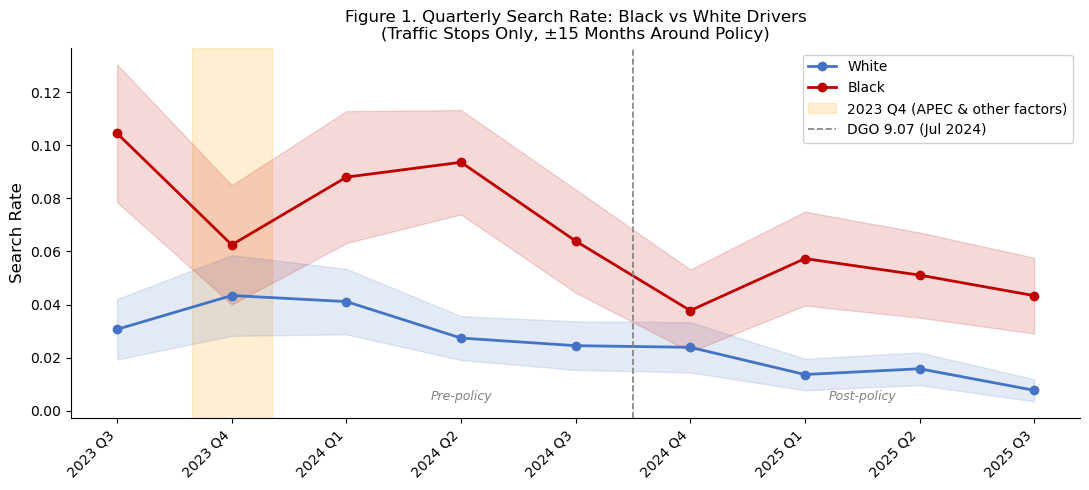

Saved: fig1_main_parallel_trends.png


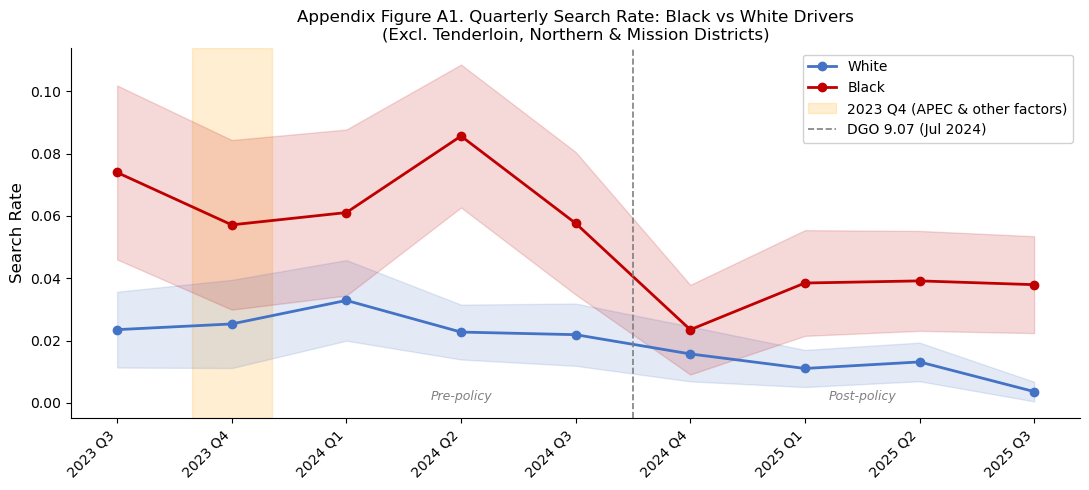

Saved: figA1_appendix_excl_anomaly.png
Event study error: 
Event study error: 

Parallel Trends Test — Three Versions

[Full sample]
  No Q4 control (baseline)                      coef=-0.000336  p=0.8453  ✓ parallel
  Control Q4 2023 dummy                         coef=-0.001860  p=0.3118  ✓ parallel
  Exclude Q4 2023 entirely                      coef=-0.001776  p=0.3369  ✓ parallel

[Excl. anomaly districts]
  No Q4 control (baseline)                      coef=0.001448  p=0.4631  ✓ parallel
  Control Q4 2023 dummy                         coef=0.000954  p=0.6472  ✓ parallel
  Exclude Q4 2023 entirely                      coef=0.000901  p=0.6675  ✓ parallel

主规格：Control Q4 2023 dummy | 另两版放附录

Table 2. Robustness: Effect of DGO 9.07 on Black-White Search Gap
Specification                                       N     Coef       p  95% CI
----------------------------------------------------------------------------------
(1) Basic DiD                                   16592  -0.0180 0.022

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读数据 & 基础处理
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv", low_memory=False)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()

df["black"]           = (df["perceived_race_code"] == 2).astype(int)
df["post_DGO"]        = (df["date"] >= policy_date).astype(int)
df["quarter"]         = df["date"].dt.to_period("Q").dt.to_timestamp()
df["quarter_of_year"] = df["date"].dt.quarter
df["month_trend"]     = (
    (df["date"].dt.year  - df["date"].dt.year.min()) * 12 +
    (df["date"].dt.month - df["date"].dt.month.min())
)
df["consent_search"] = (
    (df["searched"] == 1) &
    (df["basis_for_search_code"].astype(str)
     .str.split(",")
     .apply(lambda x: any(v.strip() == "1" for v in x)))
).astype(int)

df["q4_2023"] = (
    (df["date"] >= pd.Timestamp("2023-10-01")) &
    (df["date"] <  pd.Timestamp("2024-01-01"))
).astype(int)

df["apec_nov"] = (
    (df["date"].dt.year == 2023) &
    (df["date"].dt.month == 11)
).astype(int)

start = pd.Timestamp("2023-06-30")
end   = pd.Timestamp("2025-09-30")
df_win = df[(df["date"] >= start) & (df["date"] <= end)].copy()

anomaly = ["TENDERLOIN", "NORTHERN", "MISSION"]
df_full = df_win.copy()
df_excl = df_win[~df_win["district"].isin(anomaly)].copy()

BASE = "/Users/thisisjasmine/Desktop/ECO225/"

def fmt_q(ts):
    return f"{ts.year} Q{(ts.month-1)//3+1}"

def compute_wide(df_sub):
    qs = (
        df_sub.groupby(["quarter", "black"])["searched"]
        .agg(mean="mean", sem=lambda x: stats.sem(x), n="count")
        .reset_index()
    )
    qs["ci95"] = qs["sem"] * 1.96
    wide = qs.pivot(index="quarter", columns="black",
                    values=["mean", "ci95", "n"])
    wide.columns = ["_".join(map(str, c)) for c in wide.columns]
    return wide

# =========================
# 诊断：月度搜查率
# =========================
print("=" * 50)
print("月度搜查率诊断（2023年）")
print("=" * 50)
_diag = df_win[df_win["date"].dt.year == 2023].copy()
monthly = (
    _diag.groupby([_diag["date"].dt.to_period("M"), "black"])["searched"]
    .mean()
    .reset_index()
)
monthly.columns = ["month", "black", "search_rate"]
print(monthly.pivot(index="month", columns="black",
                    values="search_rate").round(4))
print()
print("注：Black搜查率从10月开始下降，12月APEC结束后仍未反弹")
print("→ 控制整个2023 Q4作为保守处理")

# =========================
# 通用画图函数（修复阴影和标签位置）
# =========================
def plot_trend(wide, policy_date, title, fname):
    x        = np.arange(len(wide))
    x_labels = [fmt_q(ts) for ts in wide.index]

    # 关键index
    q4_ts    = pd.Timestamp("2023-10-01")
    q1_ts    = pd.Timestamp("2024-01-01")
    q4_idx   = next((i for i, ts in enumerate(wide.index) if ts == q4_ts),  None)
    q1_idx   = next((i for i, ts in enumerate(wide.index) if ts == q1_ts),  None)
    pre_n    = len(wide[wide.index < policy_date])   # policy前季度数
    post_start = pre_n                               # post第一个季度的index

    fig, ax = plt.subplots(figsize=(11, 5))

    # 两条趋势线
    for col, label, color in [("mean_0", "White", "#4472C4"),
                               ("mean_1", "Black", "#C00000")]:
        ci_col = col.replace("mean", "ci95")
        ax.plot(x, wide[col].values, marker="o",
                label=label, color=color, linewidth=2, zorder=3)
        ax.fill_between(x,
                        (wide[col] - wide[ci_col]).values,
                        (wide[col] + wide[ci_col]).values,
                        alpha=0.15, color=color, zorder=2)

    # Q4 2023阴影：收窄到±0.35，确保不碰到相邻季度
    if q4_idx is not None:
        ax.axvspan(q4_idx - 0.35, q4_idx + 0.35,
                   alpha=0.18, color="orange",
                   label="2023 Q4 (APEC & other factors)",
                   zorder=1)

    # 政策虚线
    ax.axvline(pre_n - 0.5, color="gray", linestyle="--",
               linewidth=1.2, label="DGO 9.07 (Jul 2024)", zorder=4)

    ymin, ymax = ax.get_ylim()
    label_y = ymin + (ymax - ymin) * 0.05

    # Pre-policy标签：从2024 Q1到policy线之间的中点
    if q1_idx is not None:
        pre_label_x = (q1_idx + pre_n - 1) / 2
    else:
        pre_label_x = pre_n / 2
    ax.text(pre_label_x, label_y, "Pre-policy",
            ha="center", fontsize=9, color="gray", style="italic")

    # Post-policy标签：policy线右侧到末尾的中点
    post_label_x = post_start + (len(wide) - post_start - 1) / 2
    ax.text(post_label_x, label_y, "Post-policy",
            ha="center", fontsize=9, color="gray", style="italic")

    ax.set_ylabel("Search Rate", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(BASE + fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

# =========================
# 图1（正文）：Full sample
# =========================
wide = compute_wide(df_full)
plot_trend(
    wide, policy_date,
    title="Figure 1. Quarterly Search Rate: Black vs White Drivers\n"
          "(Traffic Stops Only, ±15 Months Around Policy)",
    fname="fig1_main_parallel_trends.png"
)

# =========================
# 图2（Appendix A1）：排除anomaly districts
# =========================
wide2 = compute_wide(df_excl)
plot_trend(
    wide2, policy_date,
    title="Appendix Figure A1. Quarterly Search Rate: Black vs White Drivers\n"
          "(Excl. Tenderloin, Northern & Mission Districts)",
    fname="figA1_appendix_excl_anomaly.png"
)

# =========================
# 图3：Event Study
# =========================
def run_event_study(df_sub, title, fname):
    d = df_sub.copy()
    d["qperiod"] = d["date"].dt.to_period("Q")
    base_q = pd.Period("2024Q2", freq="Q")
    d["rel_q"] = d["qperiod"].apply(lambda q: (q - base_q).n)

    d = d[d["rel_q"].between(-4, 3) & (d["rel_q"] != 0)].copy()

    rel_qs = sorted(d["rel_q"].unique())
    for r in rel_qs:
        d[f"q{r}"]       = (d["rel_q"] == r).astype(int)
        d[f"q{r}_black"] = d[f"q{r}"] * d["black"]

    q_terms = " + ".join([f"q{r}" for r in rel_qs])
    i_terms = " + ".join([f"q{r}_black" for r in rel_qs])
    formula = (f"searched ~ black + {q_terms} + {i_terms}"
               f" + q4_2023 + black:q4_2023 + C(district)")

    try:
        m = smf.ols(formula, data=d).fit(cov_type="HC1")
    except Exception as e:
        print(f"Event study error: {e}")
        return

    coefs = [m.params.get(f"q{r}_black", np.nan) for r in rel_qs]
    cis   = [m.conf_int().loc[f"q{r}_black"]
              if f"q{r}_black" in m.conf_int().index
              else (np.nan, np.nan) for r in rel_qs]

    all_qs = sorted(rel_qs + [0])
    all_coef, all_lo, all_hi = [], [], []
    for r in all_qs:
        if r == 0:
            all_coef.append(0); all_lo.append(0); all_hi.append(0)
        else:
            i = rel_qs.index(r)
            all_coef.append(coefs[i])
            all_lo.append(cis[i][0])
            all_hi.append(cis[i][1])

    base_ts = pd.Timestamp("2024-04-01")
    labels  = []
    for r in all_qs:
        ts = base_ts + pd.DateOffset(months=3 * r)
        labels.append(f"{ts.year} Q{(ts.month-1)//3+1}")

    x_es     = np.arange(len(all_qs))
    pre_x    = all_qs.index(0)
    policy_x = pre_x + 0.5

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(x_es, all_coef, marker="o", color="#C00000",
            linewidth=2, label="DiD coef (Black − White)", zorder=3)
    ax.fill_between(x_es, all_lo, all_hi,
                    alpha=0.15, color="#C00000", zorder=2)
    ax.axhline(0, color="black", linewidth=0.8, zorder=1)
    ax.axvline(policy_x, color="gray", linestyle="--",
               linewidth=1.2, label="DGO 9.07 (Jul 2024)", zorder=4)

    # Q4 2023 = rel_q -2，阴影同样收窄
    if -2 in all_qs:
        qx = all_qs.index(-2)
        ax.axvspan(qx - 0.35, qx + 0.35,
                   alpha=0.18, color="orange",
                   label="2023 Q4 (controlled)", zorder=0)

    ax.axvspan(-0.5, pre_x - 0.5, alpha=0.04, color="blue",  zorder=0)
    ax.axvspan(pre_x + 0.5, len(all_qs) - 0.5,
               alpha=0.04, color="red", zorder=0)

    ymin, ymax = ax.get_ylim()
    label_y = ymin + (ymax - ymin) * 0.05

    # Pre标签：rel_q=-1那个季度（紧邻基准期左边）到左端中点
    ax.text((pre_x - 1) / 2, label_y, "Pre-policy",
            ha="center", fontsize=9, color="gray", style="italic")
    ax.text(pre_x + (len(all_qs) - pre_x - 1) / 2, label_y, "Post-policy",
            ha="center", fontsize=9, color="gray", style="italic")

    ax.set_xticks(x_es)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("Differential Search Rate (Black − White)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(BASE + fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

run_event_study(
    df_full,
    "Figure 2. Event Study: Differential Search Rate (Black − White)\n"
    "(Full Sample, Baseline = 2024 Q2, Controls: District FE + 2023 Q4)",
    "fig2_event_study_full.png"
)

run_event_study(
    df_excl,
    "Appendix Figure A2. Event Study: Differential Search Rate (Black − White)\n"
    "(Excl. Tenderloin, Northern & Mission, Baseline = 2024 Q2)",
    "figA2_event_study_excl.png"
)

# =========================
# 平行趋势检验
# =========================
def pt_test(df_sub, label, exclude_q4=False, control_q4=False):
    pre = df_sub[df_sub["date"] < policy_date].copy()
    if exclude_q4:
        pre = pre[pre["q4_2023"] == 0]
    pre["mt"] = (
        (pre["date"].dt.year  - pre["date"].dt.year.min()) * 12 +
        (pre["date"].dt.month - pre["date"].dt.month.min())
    )
    pre["quarter_of_year"] = pre["date"].dt.quarter
    if control_q4:
        formula = ("searched ~ black + mt + black:mt"
                   " + C(quarter_of_year) + q4_2023 + black:q4_2023")
    else:
        formula = "searched ~ black + mt + black:mt + C(quarter_of_year)"
    m = smf.ols(formula, data=pre).fit(cov_type="HC1")
    p = m.pvalues["black:mt"]
    c = m.params["black:mt"]
    result = "✓ parallel" if p > 0.1 else "✗ non-parallel"
    print(f"  {label:<45} coef={c:.6f}  p={p:.4f}  {result}")

print("\n" + "=" * 65)
print("Parallel Trends Test — Three Versions")
print("=" * 65)
print("\n[Full sample]")
pt_test(df_full, "No Q4 control (baseline)",  exclude_q4=False, control_q4=False)
pt_test(df_full, "Control Q4 2023 dummy",      exclude_q4=False, control_q4=True)
pt_test(df_full, "Exclude Q4 2023 entirely",   exclude_q4=True,  control_q4=False)
print("\n[Excl. anomaly districts]")
pt_test(df_excl, "No Q4 control (baseline)",  exclude_q4=False, control_q4=False)
pt_test(df_excl, "Control Q4 2023 dummy",      exclude_q4=False, control_q4=True)
pt_test(df_excl, "Exclude Q4 2023 entirely",   exclude_q4=True,  control_q4=False)
print()
print("主规格：Control Q4 2023 dummy | 另两版放附录")

# =========================
# Robustness Table
# =========================
key = "post_DGO:black"
df_full["quarter_of_year"] = df_full["date"].dt.quarter
df_excl["quarter_of_year"] = df_excl["date"].dt.quarter
df_full_noq4 = df_full[df_full["q4_2023"] == 0].copy()
df_excl_noq4 = df_excl[df_excl["q4_2023"] == 0].copy()

specs = [
    ("(1) Basic DiD",
     df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district)"),

    ("(2) + Quarter FE",
     df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),

    ("(3) + QFE + Q4 control  [MAIN]",
     df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + q4_2023 + black:q4_2023"),

    ("(4) + QFE + Dist×Trend + Q4 ctrl",
     df_full,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + C(district):month_trend + q4_2023 + black:q4_2023"),

    ("(5) Excl. dist + QFE + Q4 ctrl",
     df_excl,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + q4_2023 + black:q4_2023"),

    ("(6) Excl. dist + QFE + Dist×Trend",
     df_excl,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + C(district):month_trend + q4_2023 + black:q4_2023"),

    ("(7) Drop Q4 2023 entirely",
     df_full_noq4,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),

    ("(8) Drop Q4 + Excl. dist",
     df_excl_noq4,
     "searched ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"),

    ("(9) Consent search + QFE + Q4 ctrl",
     df_full,
     "consent_search ~ post_DGO + black + post_DGO:black"
     " + low_visibility + C(district) + C(quarter_of_year)"
     " + q4_2023 + black:q4_2023"),
]

print("\n" + "=" * 82)
print("Table 2. Robustness: Effect of DGO 9.07 on Black-White Search Gap")
print("=" * 82)
print(f"{'Specification':<45} {'N':>7} {'Coef':>8} {'p':>7}  95% CI")
print("-" * 82)

for name, df_use, formula in specs:
    try:
        m  = smf.ols(formula, data=df_use).fit(cov_type="HC1")
        c  = m.params[key]
        p  = m.pvalues[key]
        lo = m.conf_int().loc[key, 0]
        hi = m.conf_int().loc[key, 1]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "  "
        print(f"{name:<45} {len(df_use):>7} {c:>8.4f} {p:>6.4f}{sig}"
              f"  [{lo:.4f}, {hi:.4f}]")
    except Exception as e:
        print(f"{name:<45} error — {e}")

print()
print("Note: * p<0.1  ** p<0.05  *** p<0.01. HC1 robust SE.")
print("Main spec: (3). Q4 2023 controlled for APEC and concurrent factors.")
print("Specs (7)(8): drop 2023 Q4 entirely as most conservative robustness check.")
print("Outcome: searched (binary) unless noted.")
print("Sample: traffic stops, Black & White drivers, ±15 months around DGO 9.07.")

Relative quarters available: [np.int64(-6), np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Event study coefficients:
    rq      coef     ci_lo     ci_hi
0   -6 -0.014959 -0.055012  0.025095
1   -5  0.030983 -0.007948  0.069913
2   -4  0.007582 -0.027863  0.043027
3   -3 -0.047129 -0.081614 -0.012644
4   -2 -0.019337 -0.054330  0.015655
5   -1  0.000000  0.000000  0.000000
6    0 -0.026803 -0.057067  0.003462
7    1 -0.052382 -0.080382 -0.024383
8    2 -0.022550 -0.050902  0.005801
9    3 -0.030932 -0.058328 -0.003535
10   4 -0.030562 -0.056562 -0.004561


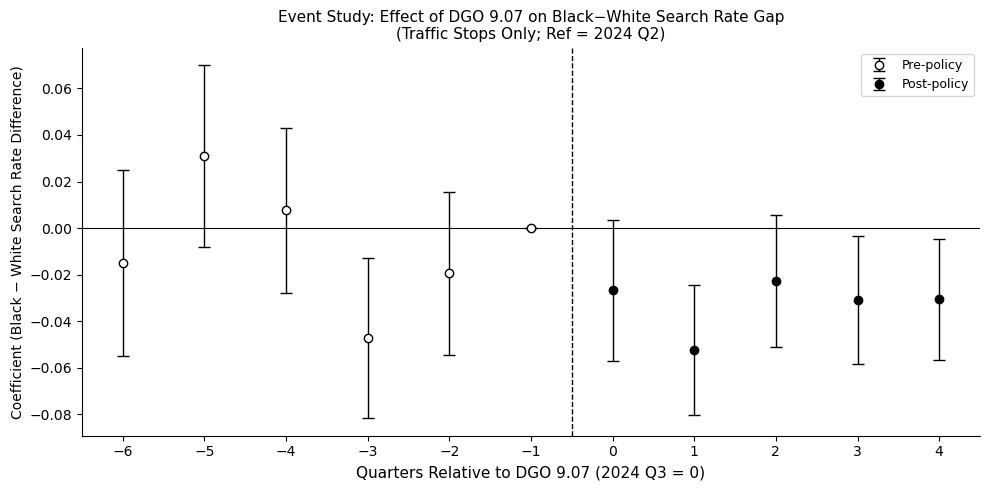

Saved: fig_event_study.png

Pre-period terms for joint test: ["C(rq, Treatment(reference='-1'))[T.-6]:black", "C(rq, Treatment(reference='-1'))[T.-5]:black", "C(rq, Treatment(reference='-1'))[T.-4]:black", "C(rq, Treatment(reference='-1'))[T.-3]:black", "C(rq, Treatment(reference='-1'))[T.-2]:black"]

Joint Wald test (pre-period = 0):
  F = 16.0236,  p = 0.0068
  → 警告：可能违背


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# =========================
# 1. 读数据
# =========================
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
                 low_memory=False)
df["date"]  = pd.to_datetime(df["date"], errors="coerce")
policy_date = pd.Timestamp("2024-07-17")

# Traffic stops, Black + White only
df = df[
    (df["perceived_race_code"].isin([2, 7])) &
    (df["reason_for_stop_code"] == 1)
].copy()
df["black"] = (df["perceived_race_code"] == 2).astype(int)

# 相对季度（0 = 政策生效季度 2024 Q3）
policy_quarter = pd.Period("2024Q3")
df["rel_quarter_int"] = (
    df["date"].dt.to_period("Q").apply(lambda q: (q - policy_quarter).n)
)

# 只用 ±6 个季度窗口
df = df[df["rel_quarter_int"].between(-6, 6)].copy()

print("Relative quarters available:", sorted(df["rel_quarter_int"].unique()))

# =========================
# 2. Event Study 回归
#    searched ~ C(rel_quarter, ref=-1) × black + black + C(rel_quarter, ref=-1)
#    基准期 = -1（政策前一个季度，即 2024 Q2）
#    提取 C(rel_quarter)[T.X]:black 的系数
# =========================
df["rq"] = df["rel_quarter_int"].astype(str)

# 基准期 = "-1"
model = smf.ols(
    "searched ~ C(rq, Treatment(reference='-1')) * black",
    data=df
).fit(cov_type="HC1")

# 提取交互项系数
params = model.params
ci     = model.conf_int()

results = []
for rq in sorted(df["rel_quarter_int"].unique()):
    if rq == -1:
        # 基准期系数为0
        results.append({"rq": rq, "coef": 0, "ci_lo": 0, "ci_hi": 0})
        continue
    term = f"C(rq, Treatment(reference='-1'))[T.{rq}]:black"
    if term in params.index:
        results.append({
            "rq":    rq,
            "coef":  params[term],
            "ci_lo": ci.loc[term, 0],
            "ci_hi": ci.loc[term, 1],
        })
    else:
        print(f"Term not found: {term}")

res = pd.DataFrame(results).sort_values("rq").reset_index(drop=True)
print("\nEvent study coefficients:")
print(res.to_string())

# =========================
# 3. 画图
# =========================
fig, ax = plt.subplots(figsize=(10, 5))

pre  = res[res["rq"] <  0]
post = res[res["rq"] >= 0]

# Pre期（空心圆）
ax.errorbar(
    pre["rq"], pre["coef"],
    yerr=[pre["coef"] - pre["ci_lo"], pre["ci_hi"] - pre["coef"]],
    fmt="o", color="black", markerfacecolor="white", markeredgecolor="black",
    capsize=4, linewidth=1, markersize=6, label="Pre-policy"
)

# Post期（实心圆）
ax.errorbar(
    post["rq"], post["coef"],
    yerr=[post["coef"] - post["ci_lo"], post["ci_hi"] - post["coef"]],
    fmt="o", color="black", markerfacecolor="black",
    capsize=4, linewidth=1, markersize=6, label="Post-policy"
)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(-0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Quarters Relative to DGO 9.07 (2024 Q3 = 0)", fontsize=11)
ax.set_ylabel("Coefficient (Black − White Search Rate Difference)", fontsize=10)
ax.set_title("Event Study: Effect of DGO 9.07 on Black−White Search Rate Gap\n"
             "(Traffic Stops Only; Ref = 2024 Q2)", fontsize=11)
ax.set_xticks(sorted(df["rel_quarter_int"].unique()))
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_event_study.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_event_study.png")

# =========================
# 4. 联合检验：pre期系数是否同时为0
# =========================
pre_terms = [
    f"C(rq, Treatment(reference='-1'))[T.{rq}]:black"
    for rq in res[res["rq"] < -1]["rq"]
]
print(f"\nPre-period terms for joint test: {pre_terms}")

if pre_terms:
    constraint = ", ".join([f"({t} = 0)" for t in pre_terms])
    wald = model.wald_test(constraint, scalar=True)
    print(f"\nJoint Wald test (pre-period = 0):")
    print(f"  F = {float(wald.statistic):.4f},  p = {wald.pvalue:.4f}")
    print("  → 平行趋势成立 ✓" if wald.pvalue > 0.1 else "  → 警告：可能违背")

In [72]:
# 在现有代码末尾加这几行
res_no3 = res[res["rq"] != -3].copy()
pre_terms_no3 = [
    f"C(rq, Treatment(reference='-1'))[T.{rq}]:black"
    for rq in res_no3[res_no3["rq"] < -1]["rq"]
]
constraint_no3 = ", ".join([f"({t} = 0)" for t in pre_terms_no3])
wald_no3 = model.wald_test(constraint_no3, scalar=True)
print(f"\nWald test excluding -3:")
print(f"  F = {float(wald_no3.statistic):.4f},  p = {wald_no3.pvalue:.4f}")
print("  → parallel trend works ✓" if wald_no3.pvalue > 0.1 else "  → 警告：可能违背")


Wald test excluding -3:
  F = 6.3673,  p = 0.1733
  → parallel trend works ✓


Stop Counts: 2023 Q3 vs Q4 by District Group and Race
q                         2023Q3  2023Q4  change_%
group              race                           
Anomaly (TL/NR/MS) Black   198.0   168.0     -15.2
                   White   284.0   217.0     -23.6
Other districts    Black   338.0   280.0     -17.2
                   White   596.0   474.0     -20.5

Black Search Rate: 2023 Q3 vs Q4 by District Group
                    n_2023Q3  n_2023Q4  rate_2023Q3  rate_2023Q4  rate_change
group                                                                        
Anomaly (TL/NR/MS)     198.0     168.0     0.156566     0.071429      -0.0851
Other districts        338.0     280.0     0.073964     0.057143      -0.0168


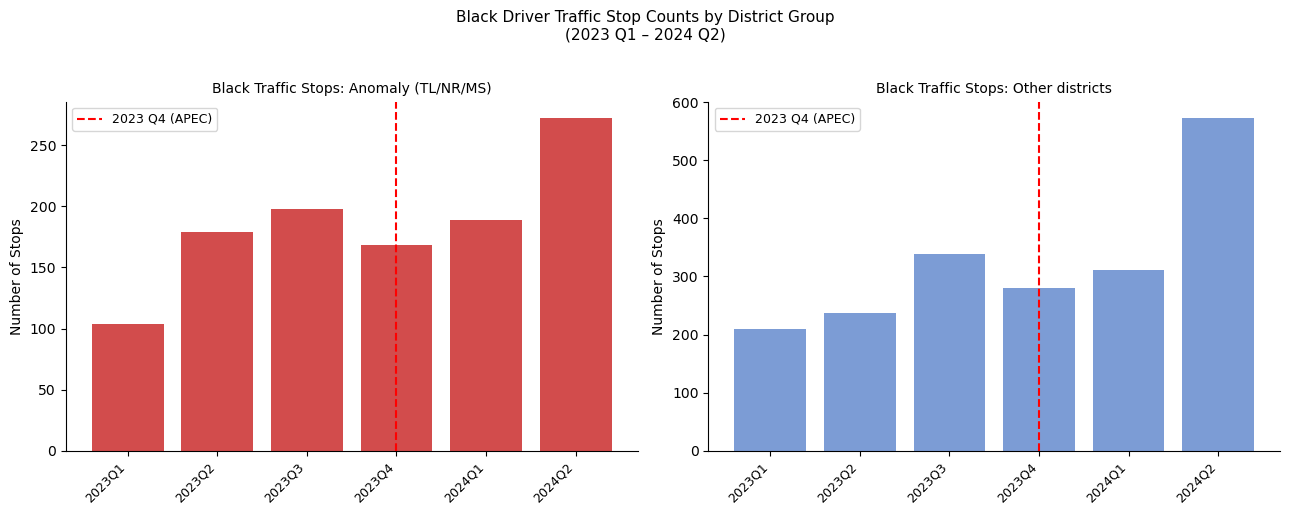


Saved: fig_apec_evidence.png

Summary for Paper
Anomaly (TL/NR/MS): Black stops Q3=198, Q4=168, change=-15.2%
Other districts: Black stops Q3=338, Q4=280, change=-17.2%


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
                 low_memory=False)
df["date"]    = pd.to_datetime(df["date"], errors="coerce")
df["quarter"] = df["date"].dt.to_period("Q").dt.to_timestamp()

# Traffic stops only
df_t = df[df["reason_for_stop_code"] == 1].copy()

anomaly = ["TENDERLOIN", "NORTHERN", "MISSION"]
df_t["group"] = df_t["district"].apply(
    lambda x: "Anomaly (TL/NR/MS)" if x in anomaly else "Other districts"
)

# =========================
# 1. Stop counts by quarter and group
# =========================
counts = (
    df_t[df_t["perceived_race_code"].isin([2, 7])]
    .groupby(["quarter", "group", "perceived_race_code"])
    .size().reset_index(name="n_stops")
)
counts["race"] = counts["perceived_race_code"].map({2: "Black", 7: "White"})
counts["q"]    = counts["quarter"].dt.to_period("Q").astype(str)

# Focus on 2023 Q3 and Q4
focus = counts[counts["q"].isin(["2023Q3", "2023Q4"])]
pivot = focus.pivot_table(
    index=["group", "race"], columns="q", values="n_stops"
)
pivot["change_%"] = ((pivot["2023Q4"] - pivot["2023Q3"]) / pivot["2023Q3"] * 100).round(1)

print("="*60)
print("Stop Counts: 2023 Q3 vs Q4 by District Group and Race")
print("="*60)
print(pivot.to_string())

# =========================
# 2. Search rates by quarter and group (Black only)
# =========================
black_t = df_t[df_t["perceived_race_code"] == 2].copy()

search_rates = (
    black_t.groupby(["quarter", "group"])["searched"]
    .agg(rate="mean", n="count")
    .reset_index()
)
search_rates["q"] = search_rates["quarter"].dt.to_period("Q").astype(str)

focus_sr = search_rates[search_rates["q"].isin(["2023Q3", "2023Q4"])]
pivot_sr = focus_sr.pivot_table(
    index="group", columns="q", values=["rate", "n"]
)
pivot_sr.columns = ["_".join(c) for c in pivot_sr.columns]
pivot_sr["rate_change"] = (pivot_sr["rate_2023Q4"] - pivot_sr["rate_2023Q3"]).round(4)

print("\n" + "="*60)
print("Black Search Rate: 2023 Q3 vs Q4 by District Group")
print("="*60)
print(pivot_sr.to_string())

# =========================
# 3. 图：Stop counts over time, anomaly vs other
# =========================
black_counts = counts[counts["race"] == "Black"].copy()
black_counts_q = black_counts[
    (black_counts["quarter"] >= "2023-01-01") &
    (black_counts["quarter"] <= "2024-06-30")
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, grp, color in [
    (axes[0], "Anomaly (TL/NR/MS)", "#C00000"),
    (axes[1], "Other districts",    "#4472C4"),
]:
    sub = black_counts_q[black_counts_q["group"] == grp].sort_values("quarter")
    ax.bar(range(len(sub)), sub["n_stops"], color=color, alpha=0.7)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(
        sub["quarter"].dt.to_period("Q").astype(str),
        rotation=45, ha="right", fontsize=9
    )
    # 标注 2023 Q4
    q4_idx = sub[sub["quarter"] == "2023-10-01"].index
    if len(q4_idx) > 0:
        pos = sub.index.get_loc(q4_idx[0])
        ax.axvline(pos, color="red", linestyle="--", linewidth=1.5,
                   label="2023 Q4 (APEC)")
        ax.legend(fontsize=9)
    ax.set_title(f"Black Traffic Stops: {grp}", fontsize=10)
    ax.set_ylabel("Number of Stops")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Black Driver Traffic Stop Counts by District Group\n"
             "(2023 Q1 – 2024 Q2)", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_apec_evidence.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_apec_evidence.png")

# =========================
# 4. 总结数字（直接引用用）
# =========================
print("\n" + "="*60)
print("Summary for Paper")
print("="*60)
for grp in ["Anomaly (TL/NR/MS)", "Other districts"]:
    row = pivot.loc[grp, "Black"] if ("Black" in pivot.index.get_level_values(1)) else None
    try:
        q3 = pivot.loc[(grp, "Black"), "2023Q3"]
        q4 = pivot.loc[(grp, "Black"), "2023Q4"]
        chg = (q4 - q3) / q3 * 100
        print(f"{grp}: Black stops Q3={int(q3)}, Q4={int(q4)}, change={chg:.1f}%")
    except:
        pass

Total Traffic Stops by Quarter (Police Activity Proxy)
group   Anomaly (TL/NR/MS)  Other districts  Total
q                                                 
2022Q4                 329             1173   1502
2023Q1                 362             1211   1573
2023Q2                 593             1242   1835
2023Q3                 635             1538   2173
2023Q4                 495             1157   1652
2024Q1                 600             1771   2371
2024Q2                 890             2749   3639

Anomaly (TL/NR/MS): Q3=635, Q4=495, change=-22.0%

Other districts: Q3=1538, Q4=1157, change=-24.8%

Stop Counts: 2023 Q3 vs Q4 by District Group and Race
q                         2023Q3  2023Q4  change_%
group              race                           
Anomaly (TL/NR/MS) Black   198.0   168.0     -15.2
                   White   284.0   217.0     -23.6
Other districts    Black   338.0   280.0     -17.2
                   White   596.0   474.0     -20.5

Black Search Rate: 2023

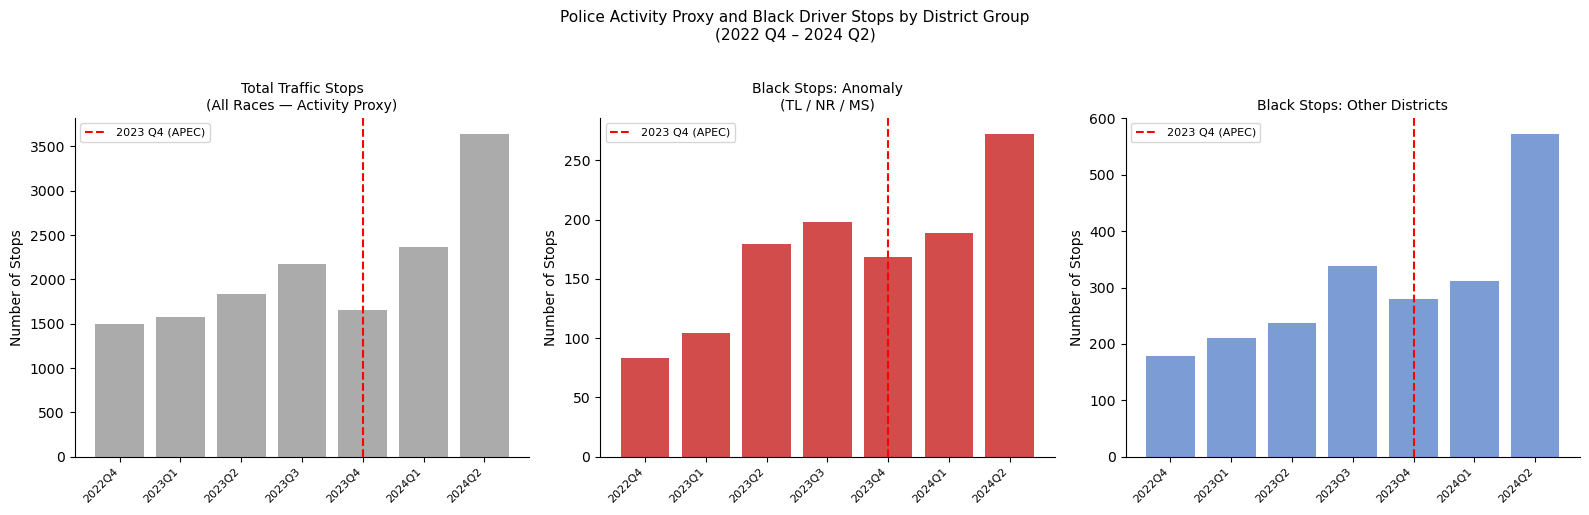


Saved: fig_apec_proxy.png

Summary for Paper
Total traffic stops: Q3=2173, Q4=1652, change=-24.0%
Anomaly (TL/NR/MS): stops Q3=198→Q4=168 (-15.2%), search rate 0.157→0.071 (-8.5pp)
Other districts: stops Q3=338→Q4=280 (-17.2%), search rate 0.074→0.057 (-1.7pp)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
                 low_memory=False)
df["date"]    = pd.to_datetime(df["date"], errors="coerce")
df["quarter"] = df["date"].dt.to_period("Q").dt.to_timestamp()
df["q"]       = df["date"].dt.to_period("Q").astype(str)

df_t = df[df["reason_for_stop_code"] == 1].copy()

anomaly = ["TENDERLOIN", "NORTHERN", "MISSION"]
df_t["group"] = df_t["district"].apply(
    lambda x: "Anomaly (TL/NR/MS)" if x in anomaly else "Other districts"
)

# =========================
# 1. Proxy：每季度 total traffic stops（所有种族）
#    用来证明 2023 Q4 整体执法强度下降
# =========================
proxy = (
    df_t.groupby(["q", "group"])
    .size().reset_index(name="total_stops")
)

focus_q = ["2022Q4", "2023Q1", "2023Q2", "2023Q3", "2023Q4", "2024Q1", "2024Q2"]
proxy_focus = proxy[proxy["q"].isin(focus_q)]

print("="*60)
print("Total Traffic Stops by Quarter (Police Activity Proxy)")
print("="*60)
pivot_proxy = proxy_focus.pivot(index="q", columns="group", values="total_stops")
pivot_proxy["Total"] = pivot_proxy.sum(axis=1)
print(pivot_proxy.to_string())

# Q3 vs Q4 变化
for grp in ["Anomaly (TL/NR/MS)", "Other districts"]:
    q3 = pivot_proxy.loc["2023Q3", grp]
    q4 = pivot_proxy.loc["2023Q4", grp]
    print(f"\n{grp}: Q3={int(q3)}, Q4={int(q4)}, change={((q4-q3)/q3*100):.1f}%")

# =========================
# 2. Stop counts by race (Black + White)
# =========================
counts = (
    df_t[df_t["perceived_race_code"].isin([2, 7])]
    .groupby(["q", "group", "perceived_race_code"])
    .size().reset_index(name="n_stops")
)
counts["race"] = counts["perceived_race_code"].map({2: "Black", 7: "White"})

focus = counts[counts["q"].isin(["2023Q3", "2023Q4"])]
pivot = focus.pivot_table(index=["group", "race"], columns="q", values="n_stops")
pivot["change_%"] = ((pivot["2023Q4"] - pivot["2023Q3"]) / pivot["2023Q3"] * 100).round(1)

print("\n" + "="*60)
print("Stop Counts: 2023 Q3 vs Q4 by District Group and Race")
print("="*60)
print(pivot.to_string())

# =========================
# 3. Black search rate by district group
# =========================
black_t = df_t[df_t["perceived_race_code"] == 2].copy()
sr = (
    black_t.groupby(["q", "group"])["searched"]
    .agg(rate="mean", n="count").reset_index()
)
focus_sr = sr[sr["q"].isin(["2023Q3", "2023Q4"])]
pivot_sr = focus_sr.pivot_table(index="group", columns="q", values=["rate", "n"])
pivot_sr.columns = ["_".join(c) for c in pivot_sr.columns]
pivot_sr["rate_change"] = (pivot_sr["rate_2023Q4"] - pivot_sr["rate_2023Q3"]).round(4)

print("\n" + "="*60)
print("Black Search Rate: 2023 Q3 vs Q4 by District Group")
print("="*60)
print(pivot_sr.to_string())

# =========================
# 4. 图：三张子图
#    左：Total stops proxy（所有种族）
#    中：Anomaly districts Black stops
#    右：Other districts Black stops
# =========================
black_counts = counts[counts["race"] == "Black"].copy()
black_counts_q = black_counts[black_counts["q"].isin(focus_q)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左图：Total stops proxy
total_q = pivot_proxy.reset_index()
axes[0].bar(range(len(total_q)), total_q["Total"],
            color="#888888", alpha=0.7)
q4_pos = total_q[total_q["q"] == "2023Q4"].index[0]
axes[0].axvline(q4_pos, color="red", linestyle="--",
                linewidth=1.5, label="2023 Q4 (APEC)")
axes[0].set_xticks(range(len(total_q)))
axes[0].set_xticklabels(total_q["q"], rotation=45, ha="right", fontsize=8)
axes[0].set_title("Total Traffic Stops\n(All Races — Activity Proxy)", fontsize=10)
axes[0].set_ylabel("Number of Stops")
axes[0].legend(fontsize=8)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# 中图 & 右图：Black stops by district group
for ax, grp, color, title in [
    (axes[1], "Anomaly (TL/NR/MS)", "#C00000", "Black Stops: Anomaly\n(TL / NR / MS)"),
    (axes[2], "Other districts",    "#4472C4", "Black Stops: Other Districts"),
]:
    sub = black_counts_q[black_counts_q["group"] == grp].sort_values("q")
    ax.bar(range(len(sub)), sub["n_stops"], color=color, alpha=0.7)
    q4_idx = sub[sub["q"] == "2023Q4"].index
    if len(q4_idx) > 0:
        pos = list(sub.index).index(q4_idx[0])
        ax.axvline(pos, color="red", linestyle="--",
                   linewidth=1.5, label="2023 Q4 (APEC)")
        ax.legend(fontsize=8)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["q"].values, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Number of Stops")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Police Activity Proxy and Black Driver Stops by District Group\n"
             "(2022 Q4 – 2024 Q2)", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_apec_proxy.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_apec_proxy.png")

# =========================
# 5. Summary for paper
# =========================
print("\n" + "="*60)
print("Summary for Paper")
print("="*60)
total_q3 = pivot_proxy.loc["2023Q3", "Total"]
total_q4 = pivot_proxy.loc["2023Q4", "Total"]
print(f"Total traffic stops: Q3={int(total_q3)}, Q4={int(total_q4)}, "
      f"change={((total_q4-total_q3)/total_q3*100):.1f}%")
for grp in ["Anomaly (TL/NR/MS)", "Other districts"]:
    q3 = pivot.loc[(grp, "Black"), "2023Q3"]
    q4 = pivot.loc[(grp, "Black"), "2023Q4"]
    sr3 = pivot_sr.loc[grp, "rate_2023Q3"]
    sr4 = pivot_sr.loc[grp, "rate_2023Q4"]
    print(f"{grp}: stops Q3={int(q3)}→Q4={int(q4)} ({((q4-q3)/q3*100):.1f}%), "
          f"search rate {sr3:.3f}→{sr4:.3f} ({(sr4-sr3)*100:+.1f}pp)")

In [35]:
import pandas as pd
import glob
import os

# Oakland 文件路径 ← 改成你的实际路径
FOLDER = "/Users/thisisjasmine/Desktop/Oak stop/"

# 所有 xlsx 文件
files = sorted(glob.glob(os.path.join(FOLDER, "*.xlsx")))
print(f"找到 {len(files)} 个文件：")
for f in files:
    print(" ", os.path.basename(f))

# 先看第一个文件的列名
print("\n=== 列名（第一个文件）===")
df0 = pd.read_excel(files[0], nrows=5)
for col in df0.columns:
    print(col)

print("\n=== 前3行 ===")
print(df0.head(3).to_string())

找到 7 个文件：
  2024-stop-data-for-website-final.xlsx
  2025-jan-jun-stop-data.xlsx
  2025-jul-dec-stop-data.xlsx
  q1-2023-stop-data-for-website.xlsx
  q2-2023-stop-data-cleaned.xlsx
  q3-2023-stop-data-for-website.xlsx
  q4-2023-stop-data-cleaned.xlsx

=== 列名（第一个文件）===
VTKReport ID
ContactDate
ContactTime
CADIncident
CaseNumber
Dispatched
EncounterType
Beat
BFOStopped
AreaStopped
Blocknumber
Street Name
K12School Name
Intelligencele
BWCActivated
Subject ReasonForEncounter
SuspicionTypeAB953
ReasonForStop
InitiatingOffenseAB953
TypeTrafficAB953
TypeTraffic_AB953
SubjectNumber
LocationVehicleOccupant
SubjectAge
SubjectAgeGroup
PerceivedAgeAB953
GenderOPD
PerceivedGenderAB953
GenderNonCon
LGBT
RaceOPD
PerceivedRaceAB953
RacePerceivedPrior
Disability
Fluency
Student
EduCode
OaklandResident
Parole
Probation
SearchRelatedActionsAB953
OtherActionsAB953
ConsentGivenPerson
ConsentGivenProperty
NoActionsAboveCK
Handcuffed
Stop Related Actions
CitationNumber
SubjectDurationOfEncounter
SearchConduct

In [36]:
import pandas as pd
import numpy as np
import glob
import os

# =========================
# 1. 合并 Oakland 数据
# =========================
FOLDER = "/Users/thisisjasmine/Desktop/Oak stop"  # ← 改成你的Oakland文件夹路径

files = sorted(glob.glob(os.path.join(FOLDER, "*.xlsx")))
print(f"找到 {len(files)} 个文件")

dfs = []
for f in files:
    print(f"  读取: {os.path.basename(f)}")
    tmp = pd.read_excel(f)
    tmp["source_file"] = os.path.basename(f)
    dfs.append(tmp)

oakland_raw = pd.concat(dfs, ignore_index=True)
print(f"\nOakland 总行数: {len(oakland_raw):,}")

# =========================
# 2. 清洗 Oakland 数据
# =========================
oakland_raw["date"] = pd.to_datetime(oakland_raw["ContactDate"], errors="coerce")

# 只保留 traffic stop（Vehicle encounter）
oakland = oakland_raw[
    oakland_raw["EncounterType"].str.strip().str.lower() == "vehicle"
].copy()
print(f"Traffic stops only: {len(oakland):,}")

# Race：只保留 Black 和 White
race_map = {
    "black/african american": "Black",
    "white":                  "White",
}
oakland["race_clean"] = (
    oakland["PerceivedRaceAB953"]
    .str.strip().str.lower()
    .map(race_map)
)
oakland = oakland[oakland["race_clean"].isin(["Black", "White"])].copy()
oakland["black"] = (oakland["race_clean"] == "Black").astype(int)
print(f"Black + White only: {len(oakland):,}")

# Searched：Yes/No → 1/0
oakland["searched"] = (
    oakland["Searched"].astype(str).str.strip().str.lower() == "person"
).astype(int)

# 月度变量
oakland["month"]   = oakland["date"].dt.to_period("M").dt.to_timestamp()
oakland["quarter"] = oakland["date"].dt.to_period("Q").dt.to_timestamp()
oakland["city"]    = "Oakland"

print(f"\nOakland date range: {oakland['date'].min()} to {oakland['date'].max()}")
print(f"Search rate Black:  {oakland[oakland['black']==1]['searched'].mean():.3f}")
print(f"Search rate White:  {oakland[oakland['black']==0]['searched'].mean():.3f}")
print(f"\nSearched values:\n{oakland_raw['Searched'].value_counts().head(10)}")

# =========================
# 3. 清洗 SF 数据（同样只保留 traffic stop, Black, White）
# =========================
sf_raw = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
    low_memory=False
)
sf_raw["date"] = pd.to_datetime(sf_raw["date"], errors="coerce")

sf = sf_raw[
    (sf_raw["perceived_race_code"].isin([2, 7])) &
    (sf_raw["reason_for_stop_code"] == 1)
].copy()

sf["black"]   = (sf["perceived_race_code"] == 2).astype(int)
sf["month"]   = sf["date"].dt.to_period("M").dt.to_timestamp()
sf["quarter"] = sf["date"].dt.to_period("Q").dt.to_timestamp()
sf["city"]    = "San Francisco"

print(f"\nSF date range: {sf['date'].min()} to {sf['date'].max()}")
print(f"SF Search rate Black: {sf[sf['black']==1]['searched'].mean():.3f}")
print(f"SF Search rate White: {sf[sf['black']==0]['searched'].mean():.3f}")

# =========================
# 4. 构建月度 Black 搜查率时间序列（两个城市）
# =========================
def monthly_search_rate(df, city):
    out = (
        df.groupby(["month", "black"])["searched"]
        .agg(mean="mean", n="count")
        .reset_index()
    )
    out["city"] = city
    return out

sf_monthly      = monthly_search_rate(sf,      "San Francisco")
oakland_monthly = monthly_search_rate(oakland, "Oakland")

combined = pd.concat([sf_monthly, oakland_monthly], ignore_index=True)

# pivot：每城市每月 Black 和 White 的搜查率
pivot = combined.pivot_table(
    index=["city", "month"],
    columns="black",
    values=["mean", "n"]
)
pivot.columns = ["_".join(map(str, c)) for c in pivot.columns]
pivot = pivot.rename(columns={
    "mean_0": "white_rate", "mean_1": "black_rate",
    "n_0":    "white_n",    "n_1":    "black_n"
})
pivot["gap"] = pivot["black_rate"] - pivot["white_rate"]
pivot = pivot.reset_index()

print("\n=== Monthly Search Rate Summary ===")
print(pivot.groupby("city")[["black_rate", "white_rate", "gap"]].mean().round(3))

# 保存
pivot.to_csv(
    "/Users/thisisjasmine/Desktop/ECO225/combined_monthly_rates.csv",
    index=False
)
print("\nSaved: combined_monthly_rates.csv")
print("\n=== 样本数据 ===")
print(pivot[pivot["city"] == "Oakland"].head(8).to_string())

找到 7 个文件
  读取: 2024-stop-data-for-website-final.xlsx
  读取: 2025-jan-jun-stop-data.xlsx
  读取: 2025-jul-dec-stop-data.xlsx
  读取: q1-2023-stop-data-for-website.xlsx
  读取: q2-2023-stop-data-cleaned.xlsx
  读取: q3-2023-stop-data-for-website.xlsx
  读取: q4-2023-stop-data-cleaned.xlsx

Oakland 总行数: 54,037
Traffic stops only: 22,764
Black + White only: 11,595

Oakland date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00
Search rate Black:  0.114
Search rate White:  0.073

Searched values:
Searched
Person                 10693
Person and Property     4414
Property                 506
Name: count, dtype: int64

SF date range: 2018-07-01 00:00:00 to 2025-09-30 00:00:00
SF Search rate Black: 0.149
SF Search rate White: 0.036

=== Monthly Search Rate Summary ===
               black_rate  white_rate    gap
city                                        
Oakland             0.116       0.072  0.044
San Francisco       0.116       0.038  0.078

Saved: combined_monthly_rates.csv

=== 样本数据 ===
      city 

In [42]:
import pandas as pd
import numpy as np
import glob
import os

# =========================
# 1. 读取并合并 Oakland 数据
#    处理两种列名格式（2023 小写 vs 2024+ 混合大小写）
# =========================
FOLDER = "/Users/thisisjasmine/Desktop/oak stop/"  # ← 改成你的路径

# DC格式的文件（误放进来的）— 按列名特征识别并跳过
DC_MARKER = "CCN_ANONYMIZED"

files = sorted(glob.glob(os.path.join(FOLDER, "*.xlsx")))
print(f"找到 {len(files)} 个文件")

dfs = []
for f in files:
    tmp = pd.read_excel(f, nrows=1)
    # 如果是DC格式，跳过
    if DC_MARKER in tmp.columns:
        print(f"  跳过（DC格式）: {os.path.basename(f)}")
        continue

    # 统一列名为小写
    full = pd.read_excel(f)
    full.columns = full.columns.str.strip().str.lower()
    full["source_file"] = os.path.basename(f)
    dfs.append(full)
    print(f"  读取: {os.path.basename(f)}  ({len(full):,} 行)")

oakland_raw = pd.concat(dfs, ignore_index=True)
print(f"\nOakland 合并总行数: {len(oakland_raw):,}")

# =========================
# 2. 清洗 Oakland
# =========================
# 日期
oakland_raw["date"] = pd.to_datetime(
    oakland_raw["contactdate"], errors="coerce"
)

# Traffic stop only（encountertype == vehicle）
oakland = oakland_raw[
    oakland_raw["encountertype"].str.strip().str.lower() == "vehicle"
].copy()
print(f"Traffic stops: {len(oakland):,}")

# Race
race_map = {
    "black/african american": "Black",
    "white":                  "White",
}
# 2023用 perceived_race_ab953，2024用 PerceivedRaceAB953（已lowercase）
race_col = "perceived_race_ab953"
oakland["race_clean"] = (
    oakland[race_col].astype(str).str.strip().str.lower().map(race_map)
)
oakland = oakland[oakland["race_clean"].isin(["Black", "White"])].copy()
oakland["black"] = (oakland["race_clean"] == "Black").astype(int)
print(f"Black + White: {len(oakland):,}")

# Searched：任何形式的搜查都算1
# 2023: searched列 | 2024: Searched列（已lowercase → searched）
oakland["searched_bin"] = (
    oakland["searched"].astype(str).str.strip().str.lower()
    .isin(["person", "person and property", "property",
           "yes", "1", "true"])
).astype(int)

# 月/季度
oakland["month"]   = oakland["date"].dt.to_period("M").dt.to_timestamp()
oakland["quarter"] = oakland["date"].dt.to_period("Q").dt.to_timestamp()
oakland["city"]    = "Oakland"

print(f"\nOakland date range: {oakland['date'].min().date()} → {oakland['date'].max().date()}")
print(f"Search rate Black:  {oakland[oakland['black']==1]['searched_bin'].mean():.3f}")
print(f"Search rate White:  {oakland[oakland['black']==0]['searched_bin'].mean():.3f}")
print(f"\nsearched 值分布:\n{oakland['searched'].value_counts().head(10)}")

# =========================
# 3. 清洗 SF
# =========================
sf_raw = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
    low_memory=False
)
sf_raw["date"] = pd.to_datetime(sf_raw["date"], errors="coerce")

sf = sf_raw[
    (sf_raw["perceived_race_code"].isin([2, 7])) &
    (sf_raw["reason_for_stop_code"] == 1)
].copy()
sf["black"]        = (sf["perceived_race_code"] == 2).astype(int)
sf["searched_bin"] = sf["searched"].astype(int)
sf["month"]        = sf["date"].dt.to_period("M").dt.to_timestamp()
sf["quarter"]      = sf["date"].dt.to_period("Q").dt.to_timestamp()
sf["city"]         = "San Francisco"

print(f"\nSF date range: {sf['date'].min().date()} → {sf['date'].max().date()}")
print(f"SF Search rate Black: {sf[sf['black']==1]['searched_bin'].mean():.3f}")
print(f"SF Search rate White: {sf[sf['black']==0]['searched_bin'].mean():.3f}")

# =========================
# 4. 月度搜查率时间序列
# =========================
def monthly_rate(df, city):
    out = (
        df.groupby(["month", "black"])["searched_bin"]
        .agg(rate="mean", n="count")
        .reset_index()
    )
    out["city"] = city
    return out

combined = pd.concat([
    monthly_rate(sf,      "San Francisco"),
    monthly_rate(oakland, "Oakland"),
], ignore_index=True)

# 只保留两个城市都有数据的月份窗口
# 政策前后各12个月
policy_date = pd.Timestamp("2024-07-17")
start = policy_date - pd.DateOffset(months=12)
end   = policy_date + pd.DateOffset(months=12)

combined = combined[
    (combined["month"] >= start) &
    (combined["month"] <= end)
].copy()

# Wide format
pivot = combined.pivot_table(
    index=["city", "month"],
    columns="black",
    values=["rate", "n"]
)
pivot.columns = ["_".join(map(str, c)) for c in pivot.columns]
pivot = pivot.rename(columns={
    "rate_0": "white_rate", "rate_1": "black_rate",
    "n_0":    "white_n",    "n_1":    "black_n"
})
pivot["gap"]  = pivot["black_rate"] - pivot["white_rate"]
pivot["post"] = (pivot.index.get_level_values("month") >= policy_date).astype(int)
pivot = pivot.reset_index()

print("\n=== 窗口内月度均值 ===")
print(pivot.groupby("city")[["black_rate", "white_rate", "gap"]].mean().round(3))

print("\n=== Oakland 月度数据（前10行）===")
print(pivot[pivot["city"] == "Oakland"].head(10).to_string())

# 保存
out_path = "/Users/thisisjasmine/Desktop/combined_monthly_rates.csv"
pivot.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

找到 7 个文件
  读取: 2024-stop-data-for-website-final.xlsx  (19,400 行)
  读取: 2025-jan-jun-stop-data.xlsx  (10,340 行)
  读取: 2025-jul-dec-stop-data.xlsx  (8,235 行)
  读取: q1-2023-stop-data-for-website.xlsx  (3,624 行)
  读取: q2-2023-stop-data-cleaned.xlsx  (3,829 行)
  读取: q3-2023-stop-data-for-website.xlsx  (4,152 行)
  读取: q4-2023-stop-data-cleaned.xlsx  (4,457 行)

Oakland 合并总行数: 54,037
Traffic stops: 31,809
Black + White: 4,601

Oakland date range: 2023-01-01 → 2023-12-31
Search rate Black:  0.240
Search rate White:  0.181

searched 值分布:
searched
Person                 543
Person and Property    459
Property                47
Name: count, dtype: int64

SF date range: 2018-07-01 → 2025-09-30
SF Search rate Black: 0.149
SF Search rate White: 0.036

=== 窗口内月度均值 ===
               black_rate  white_rate    gap
city                                        
Oakland             0.224       0.170  0.055
San Francisco       0.067       0.026  0.041

=== Oakland 月度数据（前10行）===
      city      month  white_n

In [47]:
import pandas as pd
import numpy as np
import glob
import os

# =========================
# 1. 读取并合并 Oakland 数据
# =========================
FOLDER = "/Users/thisisjasmine/Desktop/oak stop/"

DC_MARKER = "CCN_ANONYMIZED"
files = sorted(glob.glob(os.path.join(FOLDER, "*.xlsx")))
print(f"找到 {len(files)} 个文件")

dfs = []
for f in files:
    tmp = pd.read_excel(f, nrows=1)
    if DC_MARKER in tmp.columns:
        print(f"  跳过（DC格式）: {os.path.basename(f)}")
        continue
    full = pd.read_excel(f)
    full.columns = full.columns.str.strip().str.lower().str.replace(" ", "").str.replace("_", "")
    # 去掉重复列名
    full = full.loc[:, ~full.columns.duplicated()]
    full["source_file"] = os.path.basename(f)
    dfs.append(full)
    print(f"  读取: {os.path.basename(f)}  ({len(full):,} 行)")

oakland_raw = pd.concat(dfs, ignore_index=True)
print(f"\nOakland 合并总行数: {len(oakland_raw):,}")
print("列名样本（含race）:", [c for c in oakland_raw.columns if "race" in c])
print("列名样本（含date）:", [c for c in oakland_raw.columns if "date" in c])
print("列名样本（含encounter）:", [c for c in oakland_raw.columns if "encounter" in c])

# =========================
# 2. 清洗 Oakland
# =========================
oakland_raw["date"] = pd.to_datetime(oakland_raw["contactdate"], errors="coerce")

# Traffic stop
oakland = oakland_raw[
    oakland_raw["encountertype"].str.strip().str.lower() == "vehicle"
].copy()
print(f"\nTraffic stops: {len(oakland):,}")

# Race（统一后列名变成 perceivedraceab953）
race_map = {
    "black/african american": "Black",
    "white":                  "White",
}
oakland["race_clean"] = (
    oakland["perceivedraceab953"].astype(str).str.strip().str.lower().map(race_map)
)
oakland = oakland[oakland["race_clean"].isin(["Black", "White"])].copy()
oakland["black"] = (oakland["race_clean"] == "Black").astype(int)
print(f"Black + White: {len(oakland):,}")

# Searched
oakland["searched_bin"] = (
    oakland["searched"].astype(str).str.strip().str.lower()
    .isin(["person", "person and property", "property"])
).astype(int)

oakland["month"]   = oakland["date"].dt.to_period("M").dt.to_timestamp()
oakland["quarter"] = oakland["date"].dt.to_period("Q").dt.to_timestamp()
oakland["city"]    = "Oakland"

print(f"\nOakland date range: {oakland['date'].min().date()} → {oakland['date'].max().date()}")
print(f"Search rate Black:  {oakland[oakland['black']==1]['searched_bin'].mean():.3f}")
print(f"Search rate White:  {oakland[oakland['black']==0]['searched_bin'].mean():.3f}")

# =========================
# 3. 清洗 SF
# =========================
sf_raw = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
    low_memory=False
)
sf_raw["date"] = pd.to_datetime(sf_raw["date"], errors="coerce")

sf = sf_raw[
    (sf_raw["perceived_race_code"].isin([2, 7])) &
    (sf_raw["reason_for_stop_code"] == 1)
].copy()
sf["black"]        = (sf["perceived_race_code"] == 2).astype(int)
sf["searched_bin"] = sf["searched"].astype(int)
sf["month"]        = sf["date"].dt.to_period("M").dt.to_timestamp()
sf["quarter"]      = sf["date"].dt.to_period("Q").dt.to_timestamp()
sf["city"]         = "San Francisco"

print(f"\nSF date range: {sf['date'].min().date()} → {sf['date'].max().date()}")
print(f"SF Search rate Black: {sf[sf['black']==1]['searched_bin'].mean():.3f}")
print(f"SF Search rate White: {sf[sf['black']==0]['searched_bin'].mean():.3f}")

# =========================
# 4. 月度搜查率时间序列（±12个月窗口）
# =========================
policy_date = pd.Timestamp("2024-07-17")
start = policy_date - pd.DateOffset(months=12)
end   = pd.Timestamp("2025-06-30")

def monthly_rate(df, city):
    out = (
        df[(df["month"] >= start) & (df["month"] <= end)]
        .groupby(["month", "black"])["searched_bin"]
        .agg(rate="mean", n="count")
        .reset_index()
    )
    out["city"] = city
    return out

combined = pd.concat([
    monthly_rate(sf,      "San Francisco"),
    monthly_rate(oakland, "Oakland"),
], ignore_index=True)

pivot = combined.pivot_table(
    index=["city", "month"], columns="black", values=["rate", "n"]
)
pivot.columns = ["_".join(map(str, c)) for c in pivot.columns]
pivot = pivot.rename(columns={
    "rate_0": "white_rate", "rate_1": "black_rate",
    "n_0":    "white_n",    "n_1":    "black_n"
})
pivot["gap"]  = pivot["black_rate"] - pivot["white_rate"]
pivot["post"] = (pivot.index.get_level_values("month") >= policy_date).astype(int)
pivot = pivot.reset_index()

print("\n=== 窗口内月度均值 ===")
print(pivot.groupby("city")[["black_rate", "white_rate", "gap"]].mean().round(3))

print("\n=== Oakland 月度数据 ===")
print(pivot[pivot["city"] == "Oakland"].to_string())

out_path = "/Users/thisisjasmine/Desktop/ECO225/combined_monthly_rates.csv"
pivot.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

找到 7 个文件
  读取: 2024-stop-data-for-website-final.xlsx  (19,400 行)
  读取: 2025-jan-jun-stop-data.xlsx  (10,340 行)
  读取: 2025-jul-dec-stop-data.xlsx  (8,235 行)
  读取: q1-2023-stop-data-for-website.xlsx  (3,624 行)
  读取: q2-2023-stop-data-cleaned.xlsx  (3,829 行)
  读取: q3-2023-stop-data-for-website.xlsx  (4,152 行)
  读取: q4-2023-stop-data-cleaned.xlsx  (4,457 行)

Oakland 合并总行数: 54,037
列名样本（含race）: ['raceopd', 'perceivedraceab953', 'raceperceivedprior']
列名样本（含date）: ['contactdate']
列名样本（含encounter）: ['encountertype', 'subjectreasonforencounter', 'subjectdurationofencounter']

Traffic stops: 31,809
Black + White: 16,196

Oakland date range: 2023-01-01 → 2025-12-31
Search rate Black:  0.247
Search rate White:  0.154

SF date range: 2018-07-01 → 2025-09-30
SF Search rate Black: 0.149
SF Search rate White: 0.036

=== 窗口内月度均值 ===
               black_rate  white_rate    gap
city                                        
Oakland             0.242       0.141  0.101
San Francisco       0.068       0.027 

/var/folders/jy/pc_qtmgx7vg538t3wpxxq4n00000gn/T/ipykernel_45359/1999064757.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


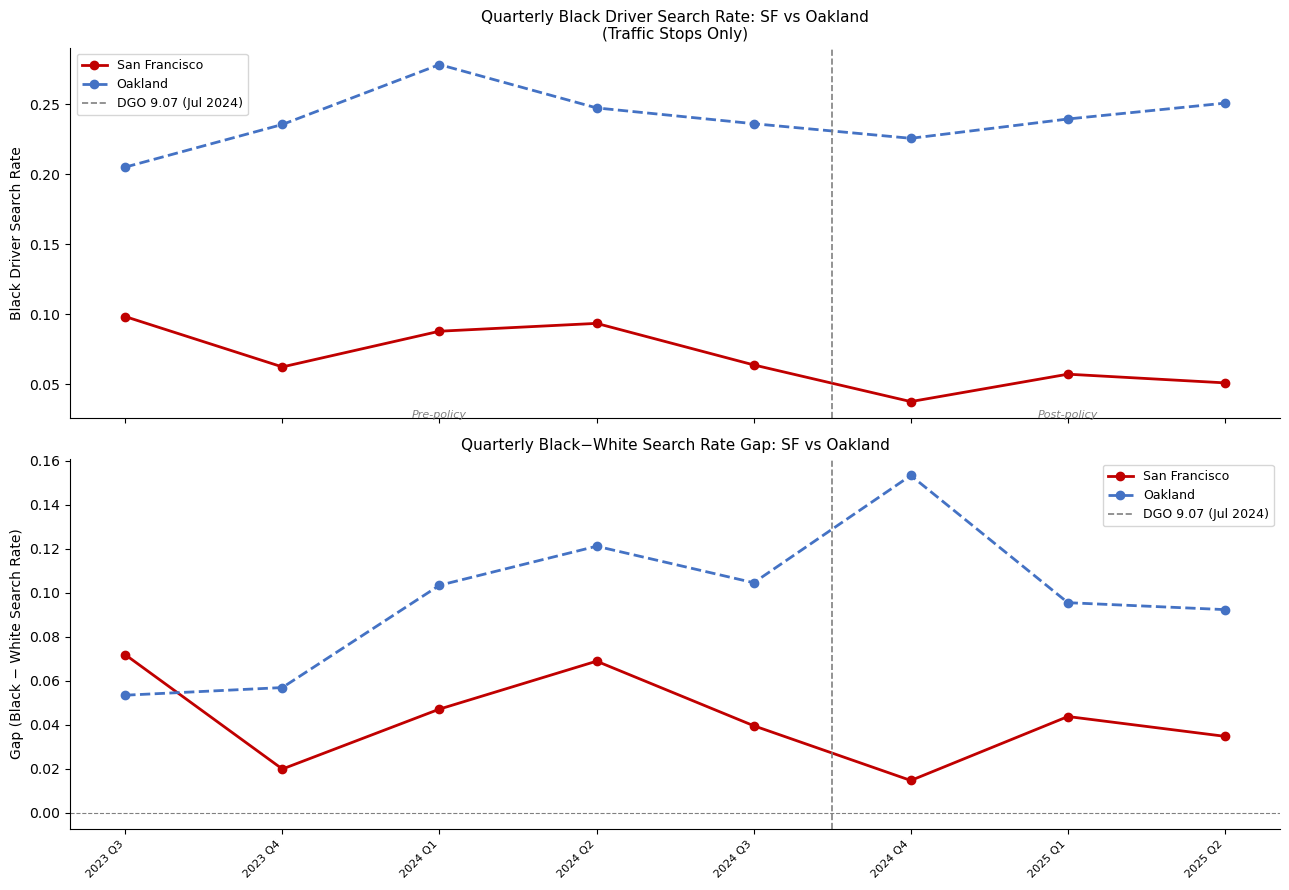

Saved: fig_did_sf_oakland.png

Parallel Trends Test: SF vs Oakland (Black search rate, pre-period)
sf:month_trend = -0.004506
p-value        = 0.2298
→ 平行趋势成立 ✓

DID: SF vs Oakland (outcome = Black search rate)
                            WLS Regression Results                            
Dep. Variable:             black_rate   R-squared:                       0.903
Model:                            WLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     193.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.30e-24
Time:                        13:14:54   Log-Likelihood:                 99.069
No. Observations:                  46   AIC:                            -190.1
Df Residuals:                      42   BIC:                            -182.8
Df Model:                           3                                         
Covariance Type:                  HC1                                         

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

# =========================
# 1. 读取合并后的月度数据
# =========================
pivot = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/combined_monthly_rates.csv"
)
pivot["month"] = pd.to_datetime(pivot["month"])
policy_date    = pd.Timestamp("2024-07-17")

# =========================
# 2. 平行趋势图：SF vs Oakland（Black搜查率）
# =========================
def fmt_q(ts):
    return f"{ts.year} Q{(ts.month-1)//3+1}"

# 季度聚合（已有月度，重新聚合到季度）
pivot["quarter"]     = pivot["month"].dt.to_period("Q").dt.to_timestamp()
pivot["post"]        = (pivot["month"] >= policy_date).astype(int)

qtr = (
    pivot.groupby(["city", "quarter"])
    .apply(lambda x: pd.Series({
        "black_rate": np.average(x["black_rate"], weights=x["black_n"]),
        "white_rate": np.average(x["white_rate"], weights=x["white_n"]),
        "gap":        np.average(x["gap"],         weights=x["black_n"] + x["white_n"]),
        "n":          x["black_n"].sum() + x["white_n"].sum(),
    }))
    .reset_index()
)

quarters = sorted(qtr["quarter"].unique())
x        = np.arange(len(quarters))
q_labels = [fmt_q(ts) for ts in quarters]
pre_n    = sum(q < policy_date for q in quarters)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# 上图：Black搜查率，SF vs Oakland
for city, color, ls in [
    ("San Francisco", "#C00000", "-"),
    ("Oakland",       "#4472C4", "--"),
]:
    sub = qtr[qtr["city"] == city].set_index("quarter").reindex(quarters)
    axes[0].plot(x, sub["black_rate"].values, marker="o",
                 color=color, linestyle=ls, linewidth=2, label=city)

axes[0].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (Jul 2024)")
axes[0].set_ylabel("Black Driver Search Rate")
axes[0].set_title("Quarterly Black Driver Search Rate: SF vs Oakland\n"
                  "(Traffic Stops Only)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].text(pre_n/2 - 0.5, axes[0].get_ylim()[0], "Pre-policy",
             ha="center", fontsize=8, color="gray", style="italic")
axes[0].text(pre_n + (len(quarters)-pre_n)/2 - 0.5, axes[0].get_ylim()[0],
             "Post-policy", ha="center", fontsize=8, color="gray", style="italic")

# 下图：Gap（Black - White），SF vs Oakland
for city, color, ls in [
    ("San Francisco", "#C00000", "-"),
    ("Oakland",       "#4472C4", "--"),
]:
    sub = qtr[qtr["city"] == city].set_index("quarter").reindex(quarters)
    axes[1].plot(x, sub["gap"].values, marker="o",
                 color=color, linestyle=ls, linewidth=2, label=city)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].axvline(pre_n - 0.5, color="gray", linestyle="--",
                linewidth=1.2, label="DGO 9.07 (Jul 2024)")
axes[1].set_ylabel("Gap (Black − White Search Rate)")
axes[1].set_title("Quarterly Black−White Search Rate Gap: SF vs Oakland",
                  fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(q_labels, rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("/Users/thisisjasmine/Desktop/ECO225/fig_did_sf_oakland.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_did_sf_oakland.png")

# =========================
# 3. 平行趋势检验（pre期，月度）
# =========================
# 需要原始个体数据，用月度聚合数据近似
# 用加权OLS：black_rate ~ trend + city + city×trend（pre期）

pre_pivot = pivot[pivot["month"] < policy_date].copy()
pre_pivot["sf"]          = (pre_pivot["city"] == "San Francisco").astype(int)
pre_pivot["month_trend"] = (
    (pre_pivot["month"].dt.year  - pre_pivot["month"].dt.year.min()) * 12 +
    (pre_pivot["month"].dt.month - pre_pivot["month"].dt.month.min())
)
pre_pivot["weights"] = pre_pivot["black_n"]

pt = smf.wls(
    "black_rate ~ sf + month_trend + sf:month_trend",
    data=pre_pivot,
    weights=pre_pivot["weights"]
).fit(cov_type="HC1")

print("\n==============================")
print("Parallel Trends Test: SF vs Oakland (Black search rate, pre-period)")
print("==============================")
print(f"sf:month_trend = {pt.params['sf:month_trend']:.6f}")
print(f"p-value        = {pt.pvalues['sf:month_trend']:.4f}")
print("→ 平行趋势成立 ✓" if pt.pvalues["sf:month_trend"] > 0.1
      else "→ 警告：可能违背")

# =========================
# 4. DID 回归（月度聚合，加权OLS）
#    black_rate ~ post + sf + post×sf
# =========================
pivot["sf"] = (pivot["city"] == "San Francisco").astype(int)

did = smf.wls(
    "black_rate ~ post + sf + post:sf",
    data=pivot,
    weights=pivot["black_n"]
).fit(cov_type="HC1")

print("\n==============================")
print("DID: SF vs Oakland (outcome = Black search rate)")
print("==============================")
print(did.summary())

key = "post:sf"
print(f"\n核心系数 post:sf = {did.params[key]:.6f}")
print(f"p-value          = {did.pvalues[key]:.4f}")
print(f"95% CI           = [{did.conf_int().loc[key,0]:.4f}, {did.conf_int().loc[key,1]:.4f}]")
if did.pvalues[key] < 0.05:
    d = "减少" if did.params[key] < 0 else "增加"
    print(f"→ 显著：DGO 9.07使SF的Black搜查率相对Oakland{d}")
else:
    print("→ 不显著")